# SRT transcription → frequency matrix → inverted index

This notebook takes a YouTube URL and:

1. extracts the video ID;
2. optionally retrieves video metadata with the official YouTube Data API v3;
3. retrieves an available timestamped transcript;
4. reconstructs sentence-like passages while preserving time windows;
5. creates a frequency matrix;
6. creates an inverted index with the columns **term**, **time window**, and **sentence**;
7. exports the results to Excel, CSV, JSON, TXT, and SRT.

## Important API distinction

- The official YouTube Data API can retrieve video metadata with an API key.
- Its `captions.list` method lists caption tracks but does not return their text.
- Downloading a caption track through `captions.download` requires OAuth authorization and sufficient permission for the video.
- Therefore, this notebook uses `SRT-transcript-api` to retrieve captions exposed by a public SRT file. It works with many manual and automatically generated captions, but it is not an official Google API and may fail when captions are unavailable or access is restricted.

Official documentation:

- https://developers.google.com/SRT/v3/docs/captions/list
- https://developers.google.com/SRT/v3/docs/captions/download
- https://github.com/jdepoix/SRT-transcript-api


## 1. Install dependencies

Run this cell once in a new environment. The notebook uses lightweight stemming by default, so it does not require a large language model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q -U pandas openpyxl nltk


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 52.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.


## 2. Imports and configuration

In [84]:
from __future__ import annotations

import html
import json
import os
import re
import unicodedata
from collections import Counter
from pathlib import Path
from typing import Iterable
from urllib.parse import parse_qs, urlparse

import pandas as pd
from nltk.stem.snowball import SnowballStemmer
!pip install youtube-transcript-api
from youtube_transcript_api import YouTubeTranscriptApi

pd.set_option("display.max_colwidth", 160)

# ---------------- USER CONFIGURATION ----------------
# Path to the subtitle/transcription file to analyse.
# Examples:
#   SRT_FILE = Path("interview.srt")
#   SRT_FILE = Path("/content/drive/MyDrive/transcriptions/interview.srt")
SRT_FILE = Path("/content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg.srt")

# Used for tokenization, stemming and stop-word selection.
# Supported here: "spanish", "english", "french", "portuguese", "italian", "german"
ANALYSIS_LANGUAGE = "spanish"

# Frequency matrix controls.
MIN_TOKEN_LENGTH = 2
MIN_FREQUENCY = 1
REMOVE_STOPWORDS = True

# Inverted-index controls.
# Empty list = index every term retained in the frequency matrix.
# Alternatively: SELECTED_TERMS = ["deporte", "discriminación", "mujer"]
SELECTED_TERMS: list[str] = []

# Use stems to connect a lemma-like term to inflected forms.
# Example: "trabajar" can match "trabajamos" or "trabajando".
USE_STEM_MATCHING = True

# Sentence reconstruction: force a split when a punctuation-free unit becomes very long.
MAX_SENTENCE_CHARACTERS = 500

OUTPUT_DIRECTORY = Path("/content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output")
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)


## 3. Helper functions

In [85]:
from typing import Iterable
import pandas as pd
import re
import unicodedata
from urllib.parse import parse_qs, urlparse
from collections import Counter
from pathlib import Path
import html

STOPWORDS = {
    "spanish": {
        "a", "al", "algo", "algunas", "algunos", "ante", "antes", "como", "con",
        "contra", "cual", "cuando", "de", "del", "desde", "donde", "durante", "e",
        "el", "ella", "ellas", "ellos", "en", "entre", "era", "erais", "eran",
        "eras", "eres", "es", "esa", "esas", "ese", "eso", "esos", "esta",
        "estaba", "estaban", "estado", "estamos", "estan", "estar", "estas",
        "este", "esto", "estos", "fue", "fueron", "ha", "hace", "hacia", "han",
        "hasta", "hay", "la", "las", "le", "les", "lo", "los", "mas", "me",
        "mi", "mis", "mucho", "muy", "no", "nos", "o", "otra", "otras", "otro",
        "otros", "para", "pero", "poco", "por", "porque", "que", "quien", "se",
        "sea", "si", "sin", "sobre", "son", "su", "sus", "tambien", "te",
        "tiene", "tienen", "todo", "todos", "tu", "tus", "un", "una", "unas",
        "uno", "unos", "y", "ya", "yo",
        "aquí", "ahí", "allí", "acá", "allá", "cerca", "lejos", "dentro", "fuera",
        "arriba", "abajo", "delante", "detrás", "encima", "debajo", "nunca", "jamás",
        "siempre", "hoy", "ayer", "mañana", "ahora", "luego", "después", "antes",
        "tarde", "temprano", "mientras", "todavía", "aún", "bien", "mal", "regular",
        "así", "deprisa", "despacio", "mejor", "peor", "bastante", "demasiado", "casi",
        "medio", "tan", "tanto", "qué", "cuál", "cuáles", "quién", "quiénes", "cuánto",
        "cuánta", "cuántos", "cuántas", "dónde", "cuando", "cómo", "eh", "ah", "oh", "uf",
        "bueno", "pues", "mira", "o sea", "sabes", "claro", "a ver", "digamos", "en fin",
        "por supuesto", "de verdad", "seré", "eres", "es", "somos", "sois", "son", "fui",
        "fuiste", "fue", "fuimos", "fuisteis", "fueron", "he", "has", "ha", "hemos", "habéis",
        "han", "había", "habías", "habíamos", "habíais", "habían", "hube", "hubiste", "hubo",
        "hubimos", "hubisteis", "hubieron", "estaré", "estarás", "estará", "estaremos", "estaréis",
        "estarán", "estuve", "estuviste", "estuvo", "estuvimos", "estuvisteis", "estuvieron",
        "tengo", "tienes", "tiene", "tenemos", "tenéis", "tienen", "tuve", "tuviste", "tuvo",
        "tuvimos", "tuvisteis", "tuvieron", "voy", "vas", "va", "vamos", "vais", "van",
        "fui", "fuiste", "fue", "fuimos", "fuisteis", "fueron", "hago", "haces", "hace", "hacemos",
        "hacéis", "hacen", "puedo", "puedes", "puede", "podemos", "podéis", "pueden", "quiero",
        "quieres", "quiere", "queremos", "queréis", "quieren", "saber", "sé", "sabes", "sabe",
        "sabemos", "sabéis", "saben", "veo", "ves", "ve", "vemos", "veis", "ven", "doy", "das",
        "da", "damos", "dais", "dan", "cosa", "cosas", "algo", "nada", "todos", "todas",
        "uno", "una", "dos", "tres", "cuatro", "cinco", "seis", "siete", "ocho", "nueve",
        "diez", "cien", "mil", "millón", "millones", "año", "años", "mes", "meses", "día",
        "días", "semana", "semanas", "hora", "horas", "minuto", "minutos", "segundo", "segundos",
        "metro", "metros", "kilómetro", "kilómetros", "kilo", "kilos", "gramo", "gramos",
        "litro", "litros", "gente", "mundo", "cada", "parte", "cierto", "cierta", "ciertos",
        "ciertas", "demás", "mismo", "misma", "mismos", "mismas", "propio", "propia",
        "propios", "propias", "tal", "tales", "diferente", "diferentes", "varios", "varias",
        "suyo", "suya", "suyos", "suyas", "cuyo", "cuya", "cuyos", "cuyas", "además", "entonces",
        "asimismo", "consecuentemente", "por consiguiente", "de esta forma", "en cambio",
        "por otra parte", "al contrario", "sin embargo", "no obstante", "pero", "mientras",
        "así que", "por lo tanto", "por eso", "por ende", "de ahí que", "dado que",
        "puesto que", "ya que", "porque", "debido a que", "en virtud de", "a causa de",
        "con el fin de", "para que", "a fin de que", "con objeto de", "aunque", "a pesar de que",
        "si bien", "aun cuando", "mientras que", "a no ser que", "en caso de que", "con tal de que",
        "a condición de que", "si", "a menos que", "como si", "tal como", "según", "conforme",
        "donde", "cuando", "en cuanto", "apenas", "tan pronto como", "antes de que",
        "después de que", "apenas", "luego que", "mientras", "siempre que", "cada vez que",
        "a medida que", "conforme", "apenas", "es decir", "o sea", "esto es", "a saber",
        "en otras palabras", "dicho de otro modo", "en suma", "en resumen", "en conclusión",
        "para terminar", "finalmente", "por último", "en primer lugar", "para empezar",
        "luego", "después", "a continuación", "asimismo", "también", "además", "incluso",
        "aparte", "ni siquiera", "por ejemplo", "en particular", "a saber", "de hecho",
        "en realidad", "en efecto", "ciertamente", "obviamente", "quizás", "tal vez",
        "probablemente", "posiblemente", "claro", "desde luego", "por supuesto", "efectivamente",
        "en general", "por lo general", "habitualmente", "normalmente", "frecuentemente",
        "a menudo", "a veces", "raras veces", "ocasionalmente", "nunca", "siempre"
    },
    "english": {
        "a", "an", "and", "are", "as", "at", "be", "been", "but", "by", "for",
        "from", "had", "has", "have", "he", "her", "hers", "him", "his", "i",
        "in", "is", "it", "its", "me", "my", "no", "not", "of", "on", "or",
        "our", "ours", "she", "so", "that", "the", "their", "theirs", "them",
        "they", "this", "to", "us", "was", "we", "were", "what", "when",
        "where", "which", "who", "will", "with", "you", "your", "yours"
    },
    "french": {
        "a", "au", "aux", "avec", "ce", "ces", "dans", "de", "des", "du",
        "elle", "en", "et", "eux", "il", "ils", "je", "la", "le", "les",
        "leur", "lui", "ma", "mais", "me", "mes", "moi", "mon", "ne", "nos",
        "notre", "nous", "on", "ou", "par", "pas", "pour", "qu", "que", "qui",
        "sa", "se", "ses", "son", "sur", "ta", "te", "tes", "toi", "ton",
        "tu", "un", "une", "vos", "votre", "vous", "y"
    },
    "portuguese": {
        "a", "ao", "aos", "as", "com", "como", "da", "das", "de", "do", "dos",
        "e", "ela", "elas", "ele", "eles", "em", "entre", "era", "essa", "esse",
        "esta", "este", "eu", "foi", "foram", "há", "isso", "isto", "já", "lhe",
        "mais", "mas", "me", "mesmo", "minha", "meu", "muito", "na", "nas",
        "não", "no", "nos", "nossa", "o", "os", "ou", "para", "pela", "pelo",
        "por", "que", "se", "sem", "ser", "seu", "sua", "também", "te", "tem",
        "têm", "tu", "um", "uma", "você", "vocês"
    },
    "italian": {
        "a", "ad", "al", "alla", "anche", "che", "chi", "con", "da", "dal",
        "dalla", "de", "dei", "del", "della", "di", "e", "è", "gli", "ha",
        "hai", "hanno", "ho", "i", "il", "in", "io", "la", "le", "lei", "lo",
        "loro", "ma", "mi", "mio", "nei", "nel", "nella", "noi", "non", "o",
        "per", "più", "quale", "questa", "questo", "se", "sei", "si", "sono",
        "su", "tra", "tu", "un", "una", "uno", "voi"
    },
    "german": {
        "aber", "als", "am", "an", "auch", "auf", "aus", "bei", "bin", "bis",
        "bist", "da", "das", "dass", "dein", "dem", "den", "der", "des", "die",
        "dies", "du", "durch", "ein", "eine", "einem", "einen", "einer", "es",
        "für", "hat", "haben", "ich", "im", "in", "ist", "mit", "nicht", "oder",
        "sein", "sie", "sind", "so", "über", "um", "und", "uns", "von", "war",
        "was", "wie", "wir", "zu", "zum", "zur"
    }
}


def extract_video_id(url_or_id: str) -> str:
    """Extract an 11-character YouTube video ID from common URL formats."""
    value = url_or_id.strip()

    if re.fullmatch(r"[\w-]{11}", value):
        return value

    parsed = urlparse(value)
    host = parsed.netloc.lower().replace("www.", "")

    if host == "youtu.be":
        candidate = parsed.path.strip("/").split("/")[0]
    elif host in {"youtube.com", "m.youtube.com", "music.youtube.com"}:
        if parsed.path == "/watch":
            candidate = parse_qs(parsed.query).get("v", [""])[0]
        elif parsed.path.startswith(("/shorts/", "/embed/", "/live/")):
            parts = parsed.path.strip("/").split("/")
            candidate = parts[1] if len(parts) > 1 else ""
        else:
            candidate = ""
    else:
        candidate = ""

    if not re.fullmatch(r"[\w-]{11}", candidate):
        raise ValueError("Could not extract a valid YouTube video ID from the supplied value.")
    return candidate


def normalise_text(text: str) -> str:
    """Lowercase and remove accents for comparison, while retaining the original output elsewhere."""
    decomposed = unicodedata.normalize("NFKD", text.lower())
    return "".join(ch for ch in decomposed if not unicodedata.combining(ch))


def tokenise(text: str) -> list[str]:
    """Unicode-aware tokenization for words and numbers."""
    return re.findall(r"[^\W_]+(?:['’\-][^\W_]+)*", text, flags=re.UNICODE)


def seconds_to_timestamp(seconds: float, srt_style: bool = False) -> str:
    """Convert seconds to HH:MM:SS.mmm or SRT HH:MM:SS,mmm."""
    milliseconds = max(0, round(float(seconds) * 1000))
    hours, remainder = divmod(milliseconds, 3_600_000)
    minutes, remainder = divmod(remainder, 60_000)
    secs, millis = divmod(remainder, 1000)
    separator = "," if srt_style else "."
    return f"{hours:02d}:{minutes:02d}:{secs:02d}{separator}{millis:03d}"


def timestamp_to_seconds(timestamp: str) -> float:
    """Convert HH:MM:SS.mmm or HH:MM:SS,mmm timestamp string to total seconds."""
    # Use re.match to capture parts directly, making parsing more robust.
    match = re.match(r'(\d{1,2}):(\d{2}):(\d{2})[,.](\d{1,3})', timestamp)
    if match:
        h, m, s, ms = map(int, match.groups())
        return h * 3600 + m * 60 + s + ms / 1000
    else:
        raise ValueError(f"Invalid timestamp format: {timestamp}")


def safe_filename(text: str, fallback: str = "youtube_video") -> str:
    value = normalise_text(text)
    value = re.sub(r"[^a-z0-9]+", "_", value).strip("_")
    return (value[:100] or fallback)


def get_video_metadata(video_id: str, api_key: str) -> dict:
    """Retrieve basic metadata with the official YouTube Data API v3."""
    if not api_key:
        return {
            "video_id": video_id,
            "title": f"YouTube video {video_id}",
            "channel": None,
            "published_at": None,
            "description": None,
            "metadata_source": "No API key supplied",
        }

    from googleapiclient.discovery import build
    from googleapiclient.errors import HttpError

    try:
        youtube = build("youtube", "v3", developerKey=api_key)
        response = youtube.videos().list(
            part="snippet",
            id=video_id,
        ).execute()
    except HttpError as exc:
        raise RuntimeError(f"YouTube Data API request failed: {exc}") from exc

    items = response.get("items", [])
    if not items:
        raise ValueError("The YouTube Data API returned no video for this ID.")

    snippet = items[0]["snippet"]
    return {
        "video_id": video_id,
        "title": snippet.get("title"),
        "channel": snippet.get("channelTitle"),
        "published_at": snippet.get("publishedAt"),
        "description": snippet.get("description"),
        "metadata_source": "YouTube Data API v3",
    }


def fetch_public_transcript(
    video_id: str,
    preferred_languages: Iterable[str],
) -> tuple[pd.DataFrame, dict]:
    """
    Retrieve a public transcript and return one row per caption segment.
    Compatible with the current youtube-transcript-api interface.
    """
    from youtube_transcript_api import YouTubeTranscriptApi

    api = YouTubeTranscriptApi()
    transcript_list = api.list(video_id)
    transcript = transcript_list.find_transcript(list(preferred_languages))
    fetched = transcript.fetch()

    rows = []
    for position, snippet in enumerate(fetched, start=1):
        text = html.unescape(str(snippet["text"]))
        text = re.sub(r"<[^>]+>", "", text) # Remove HTML tags
        text = re.sub(r"\s+", " ", text).strip()

        start = float(snippet["start"])
        duration = float(snippet["duration"])
        end = start + duration

        rows.append({
            "segment": position,
            "start_seconds": start,
            "end_seconds": end,
            "duration_seconds": max(0.0, end - start),
            "start": seconds_to_timestamp(start),
            "end": seconds_to_timestamp(end),
            "time_window": f"{seconds_to_timestamp(start)} --> {seconds_to_timestamp(end)}",
            "text": text,
        })

    transcript_metadata = {
        "language": transcript.language,
        "language_code": transcript.language_code,
        "is_generated": transcript.is_generated,
    }
    return pd.DataFrame(rows), transcript_metadata


def read_srt_file(
    srt_filepath: Path,
    ANALYSIS_LANGUAGE: str
) -> tuple[pd.DataFrame, dict]:
    """
    Read a local .srt file and return one row per subtitle segment.

    The parser accepts:
    - UTF-8 / UTF-8 with BOM;
    - Windows or Unix line endings;
    - multiline subtitle text;
    - subtitle blocks with or without an explicit numeric counter.
    """
    srt_filepath = Path(srt_filepath)

    if not srt_filepath.is_file():
        raise FileNotFoundError(
            f"SRT file not found: {srt_filepath.resolve()}\n"
            "Set SRT_FILE in the configuration cell to the correct .srt path."
        )

    content = srt_filepath.read_text(encoding="utf-8-sig")
    content = content.replace("\r\n", "\n").replace("\r", "\n").strip()

    # Split on one or more blank lines, tolerating spaces on blank lines.
    blocks = re.split(r"\n\s*\n", content)
    rows = []

    timestamp_pattern = re.compile(
        r"(?P<start>\d{1,2}:\d{2}:\d{2}[,. ]\d{1,3})\s*-->\s*"
        r"(?P<end>\d{1,2}:\d{2}:\d{2}[,. ]\d{1,3})"
    )

    for position, block in enumerate(blocks, start=1):
        lines = [line.strip() for line in block.split("\n") if line.strip()]
        if not lines:
            continue

        # Standard SRT starts with a numeric sequence number.
        if lines[0].isdigit():
            segment_num = int(lines[0])
            candidate_lines = lines[1:]
        else:
            segment_num = position
            candidate_lines = lines

        time_idx = next(
            (i for i, line in enumerate(candidate_lines) if timestamp_pattern.search(line)),
            None,
        )
        if time_idx is None:
            continue

        match = timestamp_pattern.search(candidate_lines[time_idx])
        start_ts = match.group("start")
        end_ts = match.group("end")

        text_lines = candidate_lines[time_idx + 1:]
        text = " ".join(text_lines)
        text = re.sub(r"<[^>]+>", "", text)
        text = html.unescape(text)
        text = re.sub(r"\s+", " ", text).strip()

        if not text:
            continue

        start_seconds = timestamp_to_seconds(start_ts)
        end_seconds = timestamp_to_seconds(end_ts)

        rows.append({
            "segment": segment_num,
            "start_seconds": start_seconds,
            "end_seconds": end_seconds,
            "duration_seconds": max(0.0, end_seconds - start_seconds),
            "start": seconds_to_timestamp(start_seconds),
            "end": seconds_to_timestamp(end_seconds),
            "time_window": (
                f"{seconds_to_timestamp(start_seconds)} --> "
                f"{seconds_to_timestamp(end_seconds)}"
            ),
            "text": text,
        })

    if not rows:
        raise ValueError(
            "No valid subtitle blocks were found in the SRT file. "
            "Check that it contains timestamps such as "
            "'00:00:01,000 --> 00:00:04,000'."
        )

    transcript_df = pd.DataFrame(rows).sort_values(
        ["start_seconds", "segment"]
    ).reset_index(drop=True)

    transcript_metadata = {
        "source_type": "SRT file",
        "source_file": str(srt_filepath),
        "language": ANALYSIS_LANGUAGE,
        "language_code": None,
        "is_generated": None,
    }

    return transcript_df, transcript_metadata


def get_transcript(
    video_id: str | None = None,
    preferred_languages: Iterable[str] | None = None,
    srt_filepath: Path | None = None,
    ANALYSIS_LANGUAGE: str = "english" # Default value for ANALYSIS_LANGUAGE
) -> tuple[pd.DataFrame, dict]:
    """
    Retrieve a transcript either from YouTube or a local SRT file.
    """
    if srt_filepath:
        print(f"Reading transcript from local SRT file: {srt_filepath}")
        return read_srt_file(srt_filepath, ANALYSIS_LANGUAGE)
    elif video_id and preferred_languages:
        print(f"Fetching transcript for YouTube video: {video_id}")
        return fetch_public_transcript(video_id, preferred_languages)
    else:
        raise ValueError("Either video_id and preferred_languages, or srt_filepath must be provided.")


def transcript_to_srt(transcript_df: pd.DataFrame) -> str:
    blocks = []
    for row in transcript_df.itertuples(index=False):
        blocks.append(
            f"{row.segment}\n"
            f"{seconds_to_timestamp(row.start_seconds, srt_style=True)} --> "
            f"{seconds_to_timestamp(row.end_seconds, srt_style=True)}\n"
            f"{row.text}"
        )
    return "\n\n".join(blocks) + "\n"


def rebuild_sentences(
    transcript_df: pd.DataFrame,
    max_characters: int = 500,
) -> pd.DataFrame:
    """
    Join caption fragments until sentence-ending punctuation is found.
    Each resulting unit keeps the first segment's start and the last segment's end.
    """
    completed = []
    fragments: list[str] = []
    sentence_start = None
    sentence_end = None

    for row in transcript_df.itertuples(index=False):
        parts = re.split(r"(?<=[.!?…])\s+", row.text)

        for part in parts:
            part = part.strip()
            if not part:
                continue

            if sentence_start is None:
                sentence_start = float(row.start_seconds)

            sentence_end = float(row.end_seconds)
            fragments.append(part)
            current = re.sub(r"\s+", " ", " ".join(fragments)).strip()

            has_terminal_punctuation = bool(re.search(r'[.!?…]["”’)]?\s*$', part))
            reached_length_limit = len(current) >= max_characters

            if has_terminal_punctuation or reached_length_limit:
                completed.append({
                    "start_seconds": sentence_start,
                    "end_seconds": sentence_end,
                    "start": seconds_to_timestamp(sentence_start),
                    "end": seconds_to_timestamp(sentence_end),
                    "time_window": (
                        f"{seconds_to_timestamp(sentence_start)} --> "
                        f"{seconds_to_timestamp(sentence_end)}"
                    ),
                    "sentence": current,
                })
                fragments = []
                sentence_start = None
                sentence_end = None

    if fragments and sentence_start is not None and sentence_end is not None:
        current = re.sub(r"\s+", " ", " ".join(fragments)).strip()
        completed.append({
            "start_seconds": sentence_start,
            "end_seconds": sentence_end,
            "start": seconds_to_timestamp(sentence_start),
            "end": seconds_to_timestamp(sentence_end),
            "time_window": (
                f"{seconds_to_timestamp(sentence_start)} --> "
                f"{seconds_to_timestamp(sentence_end)}"
            ),
            "sentence": current,
        })

    result = pd.DataFrame(completed)
    result.insert(0, "sentence_id", range(1, len(result) + 1))
    return result


def build_frequency_matrix(
    sentences_df: pd.DataFrame,
    language: str,
    min_token_length: int = 2,
    min_frequency: int = 1,
    remove_stopwords: bool = True,
) -> pd.DataFrame:
    """
    Create a one-video term-frequency matrix.

    Columns:
    - term: normalized surface term
    - stem: Snowball stem
    - frequency: total token count
    - sentence_frequency: number of sentence units containing the term
    - relative_frequency: occurrences divided by retained token count
    """
    language = language.lower()
    # Ensure SnowballStemmer is imported within the function or at the top level if it's used here.
    from nltk.stem.snowball import SnowballStemmer
    stemmer = SnowballStemmer(language)
    stopwords = {normalise_text(x) for x in STOPWORDS.get(language, set())}

    term_frequency: Counter[str] = Counter()
    sentence_frequency: Counter[str] = Counter()

    for sentence in sentences_df["sentence"].fillna(""):
        tokens = [normalise_text(token) for token in tokenise(sentence)]
        tokens = [
            token for token in tokens
            if len(token) >= min_token_length
            and not token.isdigit()
            and (not remove_stopwords or token not in stopwords)
        ]
        term_frequency.update(tokens)
        sentence_frequency.update(set(tokens))

    retained_total = sum(term_frequency.values()) or 1
    records = [
        {
            "term": term,
            "stem": stemmer.stem(term),
            "frequency": count,
            "sentence_frequency": sentence_frequency[term],
            "relative_frequency": count / retained_total,
        }
        for term, count in term_frequency.items()
        if count >= min_frequency
    ]

    result = pd.DataFrame(records)
    if result.empty:
        return pd.DataFrame(
            columns=["term", "stem", "frequency", "sentence_frequency", "relative_frequency"]
        )

    return result.sort_values(
        ["frequency", "sentence_frequency", "term"],
        ascending=[False, False, True],
    ).reset_index(drop=True)


def build_inverted_index(
    sentences_df: pd.DataFrame,
    frequency_df: pd.DataFrame,
    selected_terms: Iterable[str] | None,
    language: str,
    use_stem_matching: bool = True,
) -> pd.DataFrame:
    """
    Build an inverted index: term, time window and sentence.

    With stemming enabled, a selected lemma-like term can match inflected words.
    The output also reports matched forms and occurrence count in the sentence.
    """
    language = language.lower()
    from nltk.stem.snowball import SnowballStemmer
    stemmer = SnowballStemmer(language)

    if selected_terms:
        terms = list(dict.fromkeys(
            normalise_text(term.strip())
            for term in selected_terms
            if term.strip()
        ))
    else:
        terms = frequency_df["term"].tolist()

    entries = []

    for row in sentences_df.itertuples(index=False):
        original_tokens = tokenise(row.sentence)
        normalized_tokens = [normalise_text(token) for token in original_tokens]
        token_stems = [stemmer.stem(token) for token in normalized_tokens]

        for term in terms:
            target_stem = stemmer.stem(term)
            matched_positions = [
                i for i, token in enumerate(normalized_tokens)
                if token == term or (
                    use_stem_matching
                    and len(target_stem) >= 3
                    and token_stems[i] == target_stem
                )
            ]

            if matched_positions:
                matched_forms = sorted({
                    original_tokens[i] for i in matched_positions
                }, key=str.casefold)

                entries.append({
                    "term": term,
                    "time_window": row.time_window,
                    "sentence": row.sentence,
                    "matched_forms": ", ".join(matched_forms),
                    "occurrences_in_sentence": len(matched_positions),
                    "start_seconds": row.start_seconds,
                    "end_seconds": row.end_seconds,
                    "sentence_id": row.sentence_id,
                })

    result = pd.DataFrame(entries)
    if result.empty:
        return pd.DataFrame(columns=[
            "term", "time_window", "sentence", "matched_forms",
            "occurrences_in_sentence", "start_seconds", "end_seconds", "sentence_id"
        ])

    return result.sort_values(
        ["term", "start_seconds", "sentence_id"]
    ).reset_index(drop=True)


def autosize_excel_worksheet(worksheet, dataframe: pd.DataFrame) -> None:
    """Apply readable widths, filters, wrapping and frozen header rows."""
    worksheet.freeze_panes = "A2"
    worksheet.auto_filter.ref = worksheet.dimensions

    for column_cells in worksheet.columns:
        letter = column_cells[0].column_letter
        header = str(column_cells[0].value or "")
        if header in {"sentence", "text", "description"}:
            width = 90
        elif header == "time_window":
            width = 29
        else:
            values = [str(cell.value or "") for cell in column_cells[:200]]
            width = min(max(max(map(len, values), default=10) + 2, 12), 35)
        worksheet.column_dimensions[letter].width = width

    from openpyxl.styles import Alignment, Font, PatternFill

    for cell in worksheet[1]:
        cell.font = Font(bold=True, color="FFFFFF")
        cell.fill = PatternFill("solid", fgColor="1F4E78")
        cell.alignment = Alignment(horizontal="center", vertical="center")

    for row in worksheet.iter_rows(min_row=2):
        for cell in row:
            cell.alignment = Alignment(vertical="top", wrap_text=True)


def export_results(
    metadata: dict,
    transcript_metadata: dict,
    transcript_df: pd.DataFrame,
    sentences_df: pd.DataFrame,
    frequency_df: pd.DataFrame,
    inverted_index_df: pd.DataFrame,
    output_directory: Path,
) -> dict[str, Path]:
    import json
    stem = safe_filename(metadata.get("title") or metadata.get("source_id") or "transcript")
    base = output_directory / stem

    paths = {
        "excel": base.with_suffix(".xlsx"),
        "transcript_csv": Path(f"{base}_timestamped_transcript.csv"),
        "sentences_csv": Path(f"{base}_sentences.csv"),
        "frequency_csv": Path(f"{base}_frequency_matrix.csv"),
        "inverted_index_csv": Path(f"{base}_inverted_index.csv"),
        "metadata_json": Path(f"{base}_metadata.json"),
        "transcript_txt": Path(f"{base}_transcript.txt"),
        "transcript_srt": Path(f"{base}_transcript.srt"),
    }

    transcript_df.to_csv(paths["transcript_csv"], index=False, encoding="utf-8-sig")
    sentences_df.to_csv(paths["sentences_csv"], index=False, encoding="utf-8-sig")
    frequency_df.to_csv(paths["frequency_csv"], index=False, encoding="utf-8-sig")
    inverted_index_df.to_csv(paths["inverted_index_csv"], index=False, encoding="utf-8-sig")

    combined_metadata = {**metadata, **transcript_metadata}
    paths["metadata_json"].write_text(
        json.dumps(combined_metadata, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    paths["transcript_txt"].write_text(
        "\n".join(transcript_df["text"].tolist()) + "\n",
        encoding="utf-8",
    )
    paths["transcript_srt"].write_text(
        transcript_to_srt(transcript_df),
        encoding="utf-8",
    )

    metadata_df = pd.DataFrame({
        "item": list(combined_metadata.keys()),
        "value": [combined_metadata[key] for key in combined_metadata],
    })

    # Ensure openpyxl is imported for pd.ExcelWriter engine
    import openpyxl

    with pd.ExcelWriter(paths["excel"], engine="openpyxl") as writer:
        metadata_df.to_excel(writer, sheet_name="Metadata", index=False)
        transcript_df.to_excel(writer, sheet_name="Timestamped transcript", index=False)
        sentences_df.to_excel(writer, sheet_name="Sentences", index=False)
        frequency_df.to_excel(writer, sheet_name="Frequency matrix", index=False)
        inverted_index_df.to_excel(writer, sheet_name="Inverted index", index=False)

        for worksheet in writer.book.worksheets:
            corresponding = {
                "Metadata": metadata_df,
                "Timestamped transcript": transcript_df,
                "Sentences": sentences_df,
                "Frequency matrix": frequency_df,
                "Inverted index": inverted_index_df,
            }[worksheet.title]
            autosize_excel_worksheet(worksheet, corresponding)

    return paths

## 4. Read the timestamped transcription from an SRT file

Set `SRT_FILE` in the configuration cell to the local or Google Drive path of your `.srt` file. The notebook preserves each subtitle segment's timestamps and text.


In [86]:
srt_path = Path(SRT_FILE)

transcript_df, transcript_metadata = read_srt_file(srt_path, ANALYSIS_LANGUAGE)

metadata = {
    "source_id": safe_filename(srt_path.stem, fallback="transcript"),
    "title": srt_path.stem,
    "source_file": str(srt_path),
    "metadata_source": "Local SRT file",
}

print(json.dumps({**metadata, **transcript_metadata}, ensure_ascii=False, indent=2))
display(transcript_df.head(10))
print(f"Subtitle segments: {len(transcript_df):,}")

{
  "source_id": "wtpdyqlcmug",
  "title": "wtpDYqlcMUg",
  "source_file": "/content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg.srt",
  "metadata_source": "Local SRT file",
  "source_type": "SRT file",
  "language": "spanish",
  "language_code": null,
  "is_generated": null
}


,segment,start_seconds,end_seconds,duration_seconds,start,end,time_window,text
0,1,0.24,2.490,2.250,00:00:00.240,00:00:02.490,00:00:00.240 --> 00:00:02.490,Episodio 34.
1,2,2.49,8.389,5.899,00:00:02.490,00:00:08.389,00:00:02.490 --> 00:00:08.389,[Música]
2,3,28.40,31.840,3.440,00:00:28.400,00:00:31.840,00:00:28.400 --> 00:00:31.840,"Bienvenides al podcast LGBTQ, en el cual"
3,4,31.84,33.920,2.080,00:00:31.840,00:00:33.920,00:00:31.840 --> 00:00:33.920,continuamos platicando sobre la
4,5,33.92,37.399,3.479,00:00:33.920,00:00:37.399,00:00:33.920 --> 00:00:37.399,diversidad sexual.
5,6,37.48,39.200,1.720,00:00:37.480,00:00:39.200,00:00:37.480 --> 00:00:39.200,"De verdad, el español es un idioma"
6,7,39.20,41.320,2.120,00:00:39.200,00:00:41.320,00:00:39.200 --> 00:00:41.320,"machista. Y si no, ¿por qué decimos"
7,8,41.32,43.480,2.160,00:00:41.320,00:00:43.480,00:00:41.320 --> 00:00:43.480,"nosotros, aunque en un grupo la mayoría"
8,9,43.48,46.600,3.120,00:00:43.480,00:00:46.600,00:00:43.480 --> 00:00:46.600,de personas sean mujeres? Cuando alguien
9,10,46.60,49.199,2.599,00:00:46.600,00:00:49.199,00:00:46.600 --> 00:00:49.199,"dice, ""La historia del hombre no incluye"


Subtitle segments: 579


## 5. Reconstruct sentence-like units

In [87]:
sentences_df = rebuild_sentences(
    transcript_df,
    max_characters=MAX_SENTENCE_CHARACTERS,
)

display(sentences_df.head(10))
print(f"Sentence-like units: {len(sentences_df):,}")


,sentence_id,start_seconds,end_seconds,start,end,time_window,sentence
0,1,0.240,2.490,00:00:00.240,00:00:02.490,00:00:00.240 --> 00:00:02.490,Episodio 34.
1,2,2.490,37.399,00:00:02.490,00:00:37.399,00:00:02.490 --> 00:00:37.399,"[Música] Bienvenides al podcast LGBTQ, en el cual continuamos platicando sobre la diversidad sexual."
2,3,37.480,41.320,00:00:37.480,00:00:41.320,00:00:37.480 --> 00:00:41.320,"De verdad, el español es un idioma machista."
3,4,39.200,46.600,00:00:39.200,00:00:46.600,00:00:39.200 --> 00:00:46.600,"Y si no, ¿por qué decimos nosotros, aunque en un grupo la mayoría de personas sean mujeres?"
4,5,43.480,51.520,00:00:43.480,00:00:51.520,00:00:43.480 --> 00:00:51.520,"Cuando alguien dice, ""La historia del hombre no incluye la historia de la mujer."""
5,6,51.520,57.960,00:00:51.520,00:00:57.960,00:00:51.520 --> 00:00:57.960,Está bien cambiar las os por aro o por es.
6,7,54.719,60.960,00:00:54.719,00:01:00.960,00:00:54.719 --> 00:01:00.960,¿Destruiríamos el idioma si lo cambiamos así?
7,8,57.960,64.600,00:00:57.960,00:01:04.600,00:00:57.960 --> 00:01:04.600,"Y sobre todo, si lo modificamos, ¿tendría algún efecto positivo?"
8,9,64.600,69.900,00:01:04.600,00:01:09.900,00:01:04.600 --> 00:01:09.900,"Hoy preguntémonos, ¿el lenguaje inclusivo sirve de algo?"
9,10,69.900,102.960,00:01:09.900,00:01:42.960,00:01:09.900 --> 00:01:42.960,"[Música] Si alguien llega a una reunión y saluda, buenas tardes a todas y hay un hombre, probablemente este emitiría algún sonido de inconformidad o algún c..."


Sentence-like units: 179


## 6. Generate the frequency matrix

The matrix uses normalized surface forms and includes:

- absolute frequency;
- number of sentence units containing the term;
- relative frequency;
- a Snowball stem used for optional inflection-aware indexing.

The original transcript and reconstructed sentences retain their accents and capitalization.

In [88]:
frequency_df = build_frequency_matrix(
    sentences_df=sentences_df,
    language=ANALYSIS_LANGUAGE,
    min_token_length=MIN_TOKEN_LENGTH,
    min_frequency=MIN_FREQUENCY,
    remove_stopwords=REMOVE_STOPWORDS,
)

display(frequency_df.head(50))
print(f"Terms retained: {len(frequency_df):,}")


,term,stem,frequency,sentence_frequency,relative_frequency
0,personas,person,31,26,0.019770
1,lenguaje,lenguaj,26,23,0.016582
2,mujeres,mujer,23,23,0.014668
3,genero,gener,18,16,0.011480
4,masculino,masculin,15,15,0.009566
5,usar,usar,14,13,0.008929
6,decir,dec,14,12,0.008929
7,hombres,hombr,13,13,0.008291
8,uso,uso,12,12,0.007653
9,incluyente,incluyent,11,10,0.007015


Terms retained: 916


## 6.1 Exploring the frequency matrix

In [89]:
search_term = input("Enter the term to search in the frequency matrix: ")

# Normalize the search term for consistent comparison
normalized_search_term = normalise_text(search_term)

# Filter the frequency_df to find the term
found_terms = frequency_df[frequency_df['term'] == normalized_search_term]

if not found_terms.empty:
    print(f"Found '{search_term}' (normalized to '{normalized_search_term}') in the frequency matrix:")
    display(found_terms)
else:
    print(f"The term '{search_term}' (normalized to '{normalized_search_term}') was not found in the frequency matrix.")

Enter the term to search in the frequency matrix: trans
The term 'trans' (normalized to 'trans') was not found in the frequency matrix.


## 6.2 Store the frequency matrix

The frequency matrix can be stored as an Excel file in a target directory. Set `output_base_path` below to the directory where you want the file to be written.


In [92]:
# Directory where the frequency matrix will be saved.
# Example for Google Drive:
# output_base_path = Path("/content/drive/MyDrive/transcriptions/results")
output_base_path = OUTPUT_DIRECTORY
output_base_path.mkdir(parents=True, exist_ok=True)

source_title_for_filename = safe_filename(
    metadata.get("title") or metadata.get("source_id") or "transcript"
)
excel_filename = f"{source_title_for_filename}_frequency_matrix.xlsx"
full_excel_path = output_base_path / excel_filename

frequency_df.to_excel(full_excel_path, index=False)

print(f"Frequency matrix saved successfully to: {full_excel_path.resolve()}")


Frequency matrix saved successfully to: /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/wtpdyqlcmug_frequency_matrix.xlsx


## 6.3 Ploting the Top 20 most frequent terms

/tmp/ipykernel_2671/694020275.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='term', y='frequency', data=top_terms, palette='viridis')


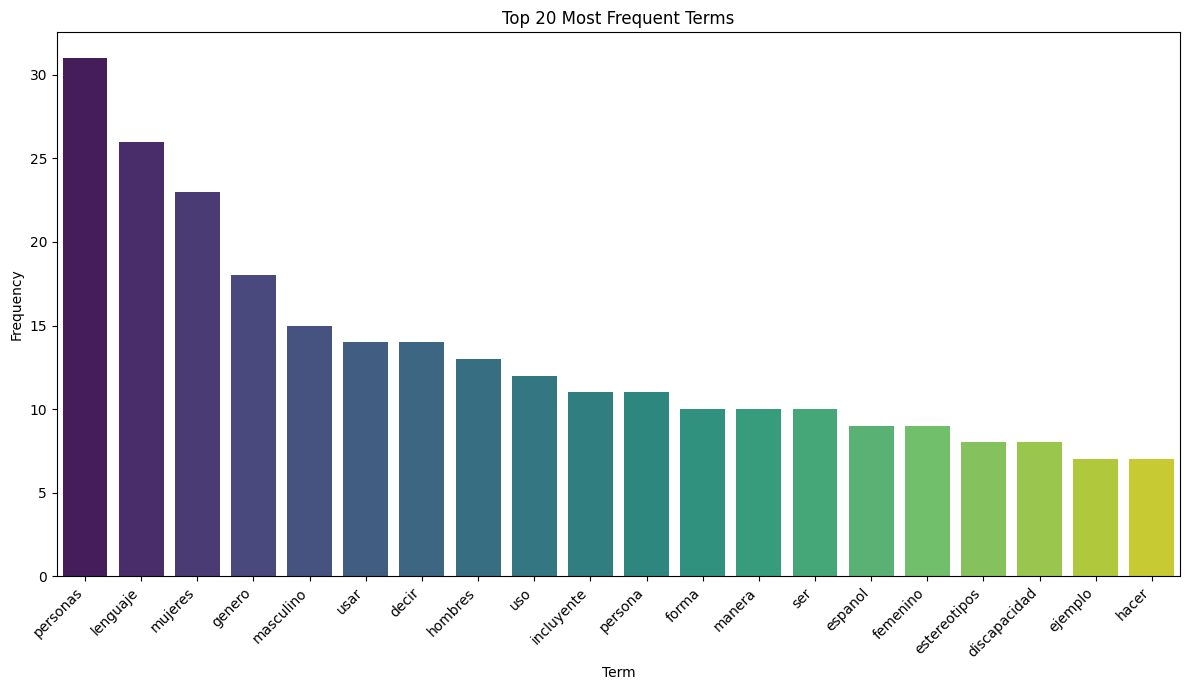

In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top N terms for visualization (e.g., top 20)
top_n = 20
top_terms = frequency_df.head(top_n)

plt.figure(figsize=(12, 7))
sns.barplot(x='term', y='frequency', data=top_terms, palette='viridis')
plt.title(f'Top {top_n} Most Frequent Terms')
plt.xlabel('Term')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6.4 Retrieving a tagged frequency matrix

The user tags the "interesting terms" in the frequency matrix excel putting a "1" on column 5 for those terms that should be then continue with the process.

This is an interactive function that gets the input path of the tagged frequency matrix and generates a new excel file containing the filtered terms.

Example:
Input: /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/SRT_transcriptions/_rccptmnjpe/_rccptmnjpe_frequency_matrix_tagged.xlsx

Output /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/SRT_transcriptions/_rccptmnjpe/_rccptmnjpe_frequency_matrix_filtered.xlsx

In [93]:
from pathlib import Path
import pandas as pd

# Get input file path from user
input_excel_path_str = input("Enter the path to the input Excel file (e.g., /content/drive/MyDrive/input.xlsx): ")
input_excel_path = Path(input_excel_path_str)

# Get output file path from user
output_excel_path_str = input("Enter the path for the output Excel file (e.g., /content/drive/MyDrive/output.xlsx): ")
output_excel_path = Path(output_excel_path_str)

try:
    # Read the input Excel file
    # Assuming 'Column A' refers to the first column (index 0)
    input_df = pd.read_excel(input_excel_path, header=None)

    # Extract terms from the first column
    terms_from_column_A = input_df.iloc[:, 0].dropna().astype(str)

    # Create a new DataFrame with the terms in the first column
    output_df = pd.DataFrame({'Term': terms_from_column_A})

    # Add three empty columns to act as placeholders (columns 2, 3, 4)
    # These will appear as 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3' in pandas
    # and empty cells in Excel, ensuring 'Marked' is the fifth column.
    output_df[None] = None
    output_df[None] = None
    output_df[None] = None

    # Add the 'Marked' column as the fifth column
    output_df['Marked'] = 1

    # Ensure the output directory exists
    output_excel_path.parent.mkdir(parents=True, exist_ok=True)

    # Save the new DataFrame to an Excel file
    output_df.to_excel(output_excel_path, index=False)

    print(f"Successfully processed terms from '{input_excel_path.name}'.")
    print(f"New Excel file saved to: {output_excel_path.resolve()}")
    print("First 5 rows of the generated Excel file:")
    display(output_df.head())

except FileNotFoundError:
    print(f"Error: The file '{input_excel_path_str}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

Enter the path to the input Excel file (e.g., /content/drive/MyDrive/input.xlsx): /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/wtpdyqlcmug_frequency_matrix_tagged.xlsx
Enter the path for the output Excel file (e.g., /content/drive/MyDrive/output.xlsx): /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/wtpdyqlcmug_frequency_matrix_filtered.xlsx
Successfully processed terms from 'wtpdyqlcmug_frequency_matrix_tagged.xlsx'.
New Excel file saved to: /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/wtpdyqlcmug_frequency_matrix_filtered.xlsx
First 5 rows of the generated Excel file:


,Term,NaN,Marked
0,term,None,1
1,personas,None,1
2,lenguaje,None,1
3,mujeres,None,1
4,genero,None,1


## 7. Manual term selection analysis

To reproduce the earlier workflow in which only selected/highlighted terms are indexed, edit `SELECTED_TERMS` in the configuration cell and rerun from there.

Leaving it empty indexes all terms retained in the frequency matrix.

Input manually selected terms: /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/SRT_transcriptions/_rCcPtmnjpE/_rccptmnjpe_frequency_matrix_filtered.xlsx

In [94]:
excel_file_path = input("/content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/rTYgX5Qtoqs/srt_analysis_output/rtygx5qtoqs_frequency_matrix_filtered.xlsx")

try:
    # Read the Excel file. Assumes terms are in the first column of the first sheet.
    selected_terms_df = pd.read_excel(excel_file_path)
    # Extract terms from the first column and convert to a list
    SELECTED_TERMS = selected_terms_df.iloc[:, 0].dropna().astype(str).tolist()
    print(f"Loaded {len(SELECTED_TERMS)} terms from '{excel_file_path}'.")
except FileNotFoundError:
    print(f"Error: The file '{excel_file_path}' was not found. Using all terms from the frequency matrix instead.")
    SELECTED_TERMS = [] # Revert to empty list to use all terms
except Exception as e:
    print(f"An error occurred while reading the Excel file: {e}. Using all terms from the frequency matrix instead.")
    SELECTED_TERMS = [] # Revert to empty list to use all terms


/content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/rTYgX5Qtoqs/srt_analysis_output/rtygx5qtoqs_frequency_matrix_filtered.xlsx/content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/wtpdyqlcmug_frequency_matrix_filtered.xlsx
Loaded 917 terms from '/content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/wtpdyqlcmug_frequency_matrix_filtered.xlsx'.


In [95]:
terms_to_index = SELECTED_TERMS or frequency_df["term"].tolist()

print(f"Terms to index: {len(terms_to_index):,}")
print(terms_to_index[:50])


Terms to index: 917
['term', 'personas', 'lenguaje', 'mujeres', 'genero', 'masculino', 'usar', 'decir', 'hombres', 'uso', 'incluyente', 'persona', 'forma', 'manera', 'ser', 'espanol', 'femenino', 'estereotipos', 'discapacidad', 'ejemplo', 'hacer', 'inclusivo', 'musica', 'palabras', 'sociedad', 'vez', 'mujer', 'sociales', 'terminos', 'ni', 'evitar', 'generico', 'hombre', 'lengua', 'alguien', 'idioma', 'latin', 'ambos', 'formas', 'grupo', 'grupos', 'igual', 'mencionar', 'muchas', 'nombre', 'nosotros', 'actualmente', 'buenas', 'final', 'nuestra']


In [96]:
# First, remove any potential duplicates from the initial terms_to_index list
# Using dict.fromkeys to preserve order while deduplicating
final_terms_to_index = list(dict.fromkeys(terms_to_index))
print(f"Terms after initial deduplication: {len(final_terms_to_index):,}")

# Filter out any generic problematic terms that might have accidentally been included,
# such as 'term' itself, often seen when reading dataframes without skipping headers.
terms_to_exclude_explicitly = {"term"} # Add any other such terms if observed

final_terms_to_index = [
    term for term in final_terms_to_index if term not in terms_to_exclude_explicitly
]
print(f"Terms after excluding explicit problematic terms ({terms_to_exclude_explicitly}): {len(final_terms_to_index):,}")

# Define a threshold for relative frequency above which terms are considered "too repetitive"
# for specific indexing, even if not in the general STOPWORDS list.
# Adjust this value based on your corpus and desired granularity.
# For example, 0.008 means terms that constitute more than 0.8% of all non-stopwords.
HIGH_RELATIVE_FREQUENCY_THRESHOLD = 0.008 # Example threshold, can be adjusted by the user

# Check if frequency_df is defined. If not, generate it.
if 'frequency_df' not in globals():
    print("frequency_df not found. Generating it now for filtering.")

    # Ensure read_srt_file is available
    if 'read_srt_file' not in globals():
        raise NameError("Function 'read_srt_file' is not defined. Please run the helper functions cell (7f4502e9) first.")

    # Ensure transcript_df is available. If not, regenerate it from SRT_FILE.
    if 'transcript_df' not in globals():
        print("transcript_df not found. Regenerating it from SRT_FILE.")
        if 'SRT_FILE' not in globals():
            raise NameError("SRT_FILE is not defined. Please run the configuration cell (d8b030c7) first.")
        if 'ANALYSIS_LANGUAGE' not in globals():
            raise NameError("ANALYSIS_LANGUAGE is not defined. Please run the configuration cell (d8b030c7) first.")

        transcript_df, transcript_metadata = read_srt_file(SRT_FILE, ANALYSIS_LANGUAGE)
        print(f"Transcript regenerated: {len(transcript_df):,} segments.")

    # Ensure rebuild_sentences is available
    if 'rebuild_sentences' not in globals():
        raise NameError("Function 'rebuild_sentences' is not defined. Please run the helper functions cell (7f4502e9) first.")

    # Ensure sentences_df is available. If not, regenerate it from transcript_df.
    if 'sentences_df' not in globals():
        print("sentences_df not found. Regenerating it from transcript_df.")
        # We already ensured transcript_df is available above
        if 'MAX_SENTENCE_CHARACTERS' not in globals():
            raise NameError("MAX_SENTENCE_CHARACTERS is not defined. Please run the configuration cell (d8b030c7) first.")

        sentences_df = rebuild_sentences(
            transcript_df,
            max_characters=MAX_SENTENCE_CHARACTERS,
        )
        print(f"Sentences regenerated: {len(sentences_df):,}")

    # Ensure build_frequency_matrix is available
    if 'build_frequency_matrix' not in globals():
        raise NameError("Function 'build_frequency_matrix' is not defined. Please run the helper functions cell (7f4502e9) first.")

    # Assuming ANALYSIS_LANGUAGE, MIN_TOKEN_LENGTH, MIN_FREQUENCY, REMOVE_STOPWORDS are defined globally.
    if 'ANALYSIS_LANGUAGE' not in globals() or \
       'MIN_TOKEN_LENGTH' not in globals() or \
       'MIN_FREQUENCY' not in globals() or \
       'REMOVE_STOPWORDS' not in globals():
        raise NameError("One or more global variables required for frequency_df (ANALYSIS_LANGUAGE, MIN_TOKEN_LENGTH, MIN_FREQUENCY, REMOVE_STOPWORDS) are not defined. Please run the configuration cell (d8b030c7) first.")

    frequency_df = build_frequency_matrix(
        sentences_df=sentences_df,
        language=ANALYSIS_LANGUAGE,
        min_token_length=MIN_TOKEN_LENGTH,
        min_frequency=MIN_FREQUENCY,
        remove_stopwords=REMOVE_STOPWORDS,
    )
    print(f"Terms retained after re-generating frequency_df: {len(frequency_df):,}")


# Identify terms in `frequency_df` that exceed this threshold
# These are candidates for removal as "muy repetidos" stopwords specific to this document.
if not frequency_df.empty:
    repetitive_terms_to_exclude = set(
        frequency_df[frequency_df['relative_frequency'] > HIGH_RELATIVE_FREQUENCY_THRESHOLD]['term'].tolist()
    )
else:
    repetitive_terms_to_exclude = set()

print(f"Identified {len(repetitive_terms_to_exclude)} terms with relative frequency > {HIGH_RELATIVE_FREQUENCY_THRESHOLD * 100:.2f}% as highly repetitive.")
if repetitive_terms_to_exclude:
    print(f"Highly repetitive terms (sample): {list(repetitive_terms_to_exclude)[:10]}")

# Filter `final_terms_to_index` to remove these highly repetitive terms
terms_to_index = [
    term for term in final_terms_to_index if term not in repetitive_terms_to_exclude
]

print(f"Final terms to index after all filtering steps: {len(terms_to_index):,}")
print(terms_to_index[:50])

Terms after initial deduplication: 917
Terms after excluding explicit problematic terms ({'term'}): 916
Identified 8 terms with relative frequency > 0.80% as highly repetitive.
Highly repetitive terms (sample): ['mujeres', 'decir', 'masculino', 'genero', 'lenguaje', 'hombres', 'usar', 'personas']
Final terms to index after all filtering steps: 908
['uso', 'incluyente', 'persona', 'forma', 'manera', 'ser', 'espanol', 'femenino', 'estereotipos', 'discapacidad', 'ejemplo', 'hacer', 'inclusivo', 'musica', 'palabras', 'sociedad', 'vez', 'mujer', 'sociales', 'terminos', 'ni', 'evitar', 'generico', 'hombre', 'lengua', 'alguien', 'idioma', 'latin', 'ambos', 'formas', 'grupo', 'grupos', 'igual', 'mencionar', 'muchas', 'nombre', 'nosotros', 'actualmente', 'buenas', 'final', 'nuestra', 'realidad', 'muchos', 'academia', 'cortesia', 'diversidad', 'episodio', 'espanola', 'imagen', 'ninos']


## 8. Generate the inverted index

In [97]:
inverted_index_df = build_inverted_index(
    sentences_df=sentences_df,
    frequency_df=frequency_df,
    selected_terms=terms_to_index,
    language=ANALYSIS_LANGUAGE,
    use_stem_matching=USE_STEM_MATCHING,
)

# The first three columns reproduce the requested index structure.
display(inverted_index_df[["term", "time_window", "sentence"]].head(50))
print(f"Inverted-index rows: {len(inverted_index_df):,}")


,term,time_window,sentence
0,abia,00:03:56.720 --> 00:04:00.680,Abus es abuelo y abuela abia.
1,abuela,00:03:56.720 --> 00:04:00.680,Abus es abuelo y abuela abia.
2,abuela,00:08:57.560 --> 00:09:07.720,El español que usamos nosotros no es el mismo que utilizaron nuestros abuelos y seguramente el del futuro va a ser super diferente al que tenemos actualmente.
3,abuelo,00:03:56.720 --> 00:04:00.680,Abus es abuelo y abuela abia.
4,abuelo,00:08:57.560 --> 00:09:07.720,El español que usamos nosotros no es el mismo que utilizaron nuestros abuelos y seguramente el del futuro va a ser super diferente al que tenemos actualmente.
5,abuelos,00:03:56.720 --> 00:04:00.680,Abus es abuelo y abuela abia.
6,abuelos,00:08:57.560 --> 00:09:07.720,El español que usamos nosotros no es el mismo que utilizaron nuestros abuelos y seguramente el del futuro va a ser super diferente al que tenemos actualmente.
7,abus,00:03:56.720 --> 00:04:00.680,Abus es abuelo y abuela abia.
8,acabo,00:04:50.000 --> 00:05:02.639,"Algunas excepciones de estas dos reglas que acabo de mencionar son las palabras día y mano, las cuales aún no se sabe el porqué de ellas."
9,academia,00:05:02.639 --> 00:05:14.240,"Entonces es fácil entender porque la Real Academia Española considera que la palabra como nosotros, amigos, vecinos, aunque estén en masculino, incluyen tan..."


Inverted-index rows: 2,588


## 9. Export all results

The Excel workbook contains these sheets:

- `Metadata`
- `Timestamped transcript`
- `Sentences`
- `Frequency matrix`
- `Inverted index`

Separate CSV, JSON, TXT and SRT files are also generated.

In [98]:
paths = export_results(
    metadata=metadata,
    transcript_metadata=transcript_metadata,
    transcript_df=transcript_df,
    sentences_df=sentences_df,
    frequency_df=frequency_df,
    inverted_index_df=inverted_index_df,
    output_directory=OUTPUT_DIRECTORY,
)

for kind, path in paths.items():
    print(f"{kind:22s}: {path.resolve()}")


excel                 : /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/wtpdyqlcmug.xlsx
transcript_csv        : /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/wtpdyqlcmug_timestamped_transcript.csv
sentences_csv         : /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/wtpdyqlcmug_sentences.csv
frequency_csv         : /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/wtpdyqlcmug_frequency_matrix.csv
inverted_index_csv    : /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/wtpdyqlcmug_inverted_index.csv
metadata_json         : /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/wtpdyqlc

## 10. Optional: inspect a particular term

Change `TERM_TO_INSPECT` and run the cell.

In [99]:
TERM_TO_INSPECT = "afeminados"

matches = inverted_index_df[
    inverted_index_df["term"].eq(normalise_text(TERM_TO_INSPECT))
][["term", "time_window", "sentence", "matched_forms", "occurrences_in_sentence"]]

display(matches)


,term,time_window,sentence,matched_forms,occurrences_in_sentence
46,afeminados,00:15:41.319 --> 00:16:01.680,"Los inadecuados son discapacitado, minusválido, ciego, invidente, inválido, cojo, paralítico, sordito, sordomudo, loco, enano, minorías étnicas, indígenas, ...",afeminados,1


## Methodological cautions

1. **Caption timestamps are segment timestamps, not word-level timestamps.** The resulting sentence time window begins with the first caption fragment and ends with the last fragment used to reconstruct that sentence.
2. **Automatic captions contain recognition errors.** The frequency matrix and index inherit those errors.
3. **Sentence reconstruction is heuristic.** Spoken language often lacks punctuation, and automatic captions may insert punctuation inconsistently.
4. **Stemming can create false matches.** Disable `USE_STEM_MATCHING` for strict surface-form matching.
5. **Public transcript access is not guaranteed.** Videos may lack captions, restrict access, or change availability.
6. **Respect copyright, privacy, consent and YouTube’s terms.** Use transcripts only when your intended analysis and redistribution are permitted.


# Graph extension: term relations, visualization, Neo4j and communities

The following sections extend the previous pipeline by converting co-occurrences among indexed terms into a weighted graph.

## Graph model

- A **Term** node represents one normalized term.
- A **RELATED_TO** edge connects two terms that occur in the same reconstructed sentence.
- The edge weight is the number of shared sentence contexts.
- Each edge stores all associated time windows and supporting sentence identifiers.
- Node properties include frequency, sentence frequency, degree, weighted degree and community membership.

The local workflow uses NetworkX for graph analysis and PyVis for interactive visualization. The optional database workflow stores the same model in Neo4j and provides Cypher and Graph Data Science queries.


## 11. Install graph dependencies

In [46]:
%pip install -q -U networkx pyvis python-louvain neo4j

## 12. Graph configuration

In [100]:
# A relation exists when two indexed terms occur in the same reconstructed sentence.
# Raise this threshold to obtain a smaller and more readable graph.
MIN_SHARED_CONTEXTS = 2

# Interactive visualization limits. These affect only the displayed subgraph,
# not the full graph or exported relationship table.
VISUALIZATION_MAX_NODES = 120
VISUALIZATION_MAX_EDGES = 500
VISUALIZATION_MIN_WEIGHT = 2

# Community algorithm:
# - "louvain": weighted modularity communities via python-louvain
# - "greedy": NetworkX greedy modularity communities
COMMUNITY_ALGORITHM = "louvain"

# Output files
RELATIONSHIPS_CSV = OUTPUT_DIRECTORY / "term_relationships.csv"
GRAPH_GRAPHML = OUTPUT_DIRECTORY / "term_relationships.graphml"
GRAPH_GEXF = OUTPUT_DIRECTORY / "term_relationships.gexf"
GRAPH_HTML = OUTPUT_DIRECTORY / "term_relationships_interactive.html"
COMMUNITIES_CSV = OUTPUT_DIRECTORY / "term_communities.csv"


## 13. Build the term relationship table

In [101]:
from collections import defaultdict
from itertools import combinations

import networkx as nx
import numpy as np


def canonicalise_terms(terms: Iterable[str]) -> list[str]:
    """
    Normalize terms and remove duplicates such as 'Diversidad'/'diversidad'.
    The graph uses normalized labels to prevent duplicate nodes caused only by casing or accents.
    """
    return list(dict.fromkeys(
        normalise_text(term.strip())
        for term in terms
        if str(term).strip()
    ))


def matched_terms_in_sentence(
    sentence: str,
    terms: Iterable[str],
    language: str,
    use_stem_matching: bool = True,
) -> dict[str, list[str]]:
    """
    Return {canonical_term: [surface forms]} for terms found in one sentence.
    """
    stemmer = SnowballStemmer(language.lower())
    original_tokens = tokenise(sentence)
    normalized_tokens = [normalise_text(token) for token in original_tokens]
    token_stems = [stemmer.stem(token) for token in normalized_tokens]

    matches: dict[str, list[str]] = {}

    for term in canonicalise_terms(terms):
        target_stem = stemmer.stem(term)
        positions = [
            position
            for position, token in enumerate(normalized_tokens)
            if token == term
            or (
                use_stem_matching
                and len(target_stem) >= 3
                and token_stems[position] == target_stem
            )
        ]

        # Optional handling for frequent acronym/prefix forms.
        if term in {"lgbt", "lgbtq"}:
            positions = sorted(set(
                positions
                + [
                    i for i, token in enumerate(normalized_tokens)
                    if token.startswith("lgbt")
                ]
            ))

        if term == "tran":
            positions = sorted(set(
                positions
                + [
                    i for i, token in enumerate(normalized_tokens)
                    if token in {"tran", "trans"} or token.startswith("trans")
                ]
            ))

        if positions:
            matches[term] = sorted(
                {original_tokens[i] for i in positions},
                key=str.casefold,
            )

    return matches


def build_relationship_table(
    sentences_df: pd.DataFrame,
    terms: Iterable[str],
    language: str,
    use_stem_matching: bool = True,
    min_shared_contexts: int = 1,
) -> pd.DataFrame:
    """
    Aggregate pairwise term co-occurrences.

    One row represents one undirected term pair. Time windows, sentence IDs,
    supporting sentences and matched surface forms are retained as lists.
    """
    aggregate = defaultdict(lambda: {
        "time_windows": [],
        "sentence_ids": [],
        "supporting_sentences": [],
        "source_forms": set(),
        "target_forms": set(),
    })

    canonical_terms = canonicalise_terms(terms)

    for row in sentences_df.itertuples(index=False):
        matches = matched_terms_in_sentence(
            sentence=row.sentence,
            terms=canonical_terms,
            language=language,
            use_stem_matching=use_stem_matching,
        )
        present_terms = sorted(matches)

        for source, target in combinations(present_terms, 2):
            key = (source, target)
            record = aggregate[key]
            record["time_windows"].append(row.time_window)
            record["sentence_ids"].append(int(row.sentence_id))
            record["supporting_sentences"].append(row.sentence)
            record["source_forms"].update(matches[source])
            record["target_forms"].update(matches[target])

    rows = []
    for (source, target), record in aggregate.items():
        weight = len(record["sentence_ids"])
        if weight < min_shared_contexts:
            continue

        unique_windows = list(dict.fromkeys(record["time_windows"]))
        unique_ids = list(dict.fromkeys(record["sentence_ids"]))
        unique_sentences = list(dict.fromkeys(record["supporting_sentences"]))

        rows.append({
            "source": source,
            "target": target,
            "relation": "CO_OCCURS_IN_SENTENCE",
            "weight": weight,
            "distinct_time_windows": len(unique_windows),
            "time_windows": unique_windows,
            "sentence_ids": unique_ids,
            "supporting_sentences": unique_sentences,
            "source_forms": sorted(record["source_forms"], key=str.casefold),
            "target_forms": sorted(record["target_forms"], key=str.casefold),
        })

    result = pd.DataFrame(rows)
    if result.empty:
        return pd.DataFrame(columns=[
            "source", "target", "relation", "weight", "distinct_time_windows",
            "time_windows", "sentence_ids", "supporting_sentences",
            "source_forms", "target_forms",
        ])

    return result.sort_values(
        ["weight", "source", "target"],
        ascending=[False, True, True],
    ).reset_index(drop=True)


relationship_df = build_relationship_table(
    sentences_df=sentences_df,
    terms=frequency_df["term"].tolist(),
    language=ANALYSIS_LANGUAGE,
    use_stem_matching=USE_STEM_MATCHING,
    min_shared_contexts=MIN_SHARED_CONTEXTS,
)

display(
    relationship_df[
        ["source", "target", "weight", "time_windows"]
    ].head(30)
)
print(f"Relations retained: {len(relationship_df):,}")

,source,target,weight,time_windows
0,persona,personas,30,"[00:00:39.200 --> 00:00:46.600, 00:01:09.900 --> 00:01:42.960, 00:02:34.239 --> 00:02:51.159, 00:02:51.159 --> 00:03:01.640, 00:03:01.640 --> 00:03:17.599, ..."
1,generaciones,generan,27,"[00:01:42.960 --> 00:01:51.680, 00:01:59.640 --> 00:02:07.920, 00:02:34.239 --> 00:02:51.159, 00:02:47.519 --> 00:02:51.159, 00:03:23.640 --> 00:03:36.000, ..."
2,generaciones,generico,27,"[00:01:42.960 --> 00:01:51.680, 00:01:59.640 --> 00:02:07.920, 00:02:34.239 --> 00:02:51.159, 00:02:47.519 --> 00:02:51.159, 00:03:23.640 --> 00:03:36.000, ..."
3,generaciones,genero,27,"[00:01:42.960 --> 00:01:51.680, 00:01:59.640 --> 00:02:07.920, 00:02:34.239 --> 00:02:51.159, 00:02:47.519 --> 00:02:51.159, 00:03:23.640 --> 00:03:36.000, ..."
4,generaciones,generos,27,"[00:01:42.960 --> 00:01:51.680, 00:01:59.640 --> 00:02:07.920, 00:02:34.239 --> 00:02:51.159, 00:02:47.519 --> 00:02:51.159, 00:03:23.640 --> 00:03:36.000, ..."
5,generan,generico,27,"[00:01:42.960 --> 00:01:51.680, 00:01:59.640 --> 00:02:07.920, 00:02:34.239 --> 00:02:51.159, 00:02:47.519 --> 00:02:51.159, 00:03:23.640 --> 00:03:36.000, ..."
6,generan,genero,27,"[00:01:42.960 --> 00:01:51.680, 00:01:59.640 --> 00:02:07.920, 00:02:34.239 --> 00:02:51.159, 00:02:47.519 --> 00:02:51.159, 00:03:23.640 --> 00:03:36.000, ..."
7,generan,generos,27,"[00:01:42.960 --> 00:01:51.680, 00:01:59.640 --> 00:02:07.920, 00:02:34.239 --> 00:02:51.159, 00:02:47.519 --> 00:02:51.159, 00:03:23.640 --> 00:03:36.000, ..."
8,generico,genero,27,"[00:01:42.960 --> 00:01:51.680, 00:01:59.640 --> 00:02:07.920, 00:02:34.239 --> 00:02:51.159, 00:02:47.519 --> 00:02:51.159, 00:03:23.640 --> 00:03:36.000, ..."
9,generico,generos,27,"[00:01:42.960 --> 00:01:51.680, 00:01:59.640 --> 00:02:07.920, 00:02:34.239 --> 00:02:51.159, 00:02:47.519 --> 00:02:51.159, 00:03:23.640 --> 00:03:36.000, ..."


Relations retained: 2,766


## 14. Build the NetworkX graph

Node size can later be based on weighted degree or transcript frequency. Each edge carries the full list of time windows, sentence IDs and supporting sentences.

In [49]:
!pip install -q networkx

In [102]:
import networkx as nx
import pandas as pd
from community import community_louvain # Added import for community detection

def detect_communities(
    graph: nx.Graph,
    algorithm: str = "louvain",
) -> tuple[dict[str, int], pd.DataFrame]:
    """
    Detect weighted communities and return:
    - node -> community identifier
    - tabular node/community summary
    """
    if graph.number_of_nodes() == 0:
        return {}, pd.DataFrame()

    if algorithm == "louvain":
        try:
            partition = community_louvain.best_partition(
                graph,
                weight="weight",
                random_state=42,
            )
        except ImportError as exc:
            raise ImportError(
                "Install python-louvain or choose COMMUNITY_ALGORITHM='greedy'."
            ) from exc

    elif algorithm == "greedy":
        detected = nx.community.greedy_modularity_communities(
            graph,
            weight="weight",
        )
        partition = {
            node: community_id
            for community_id, members in enumerate(detected)
            for node in members
        }
    else:
        raise ValueError("COMMUNITY_ALGORITHM must be 'louvain' or 'greedy'.")

    nx.set_node_attributes(graph, partition, "community")

    rows = []
    for node, attributes in graph.nodes(data=True):
        rows.append({
            "term": node,
            "community": int(partition[node]),
            "frequency": int(attributes.get("frequency", 0)),
            "sentence_frequency": int(attributes.get("sentence_frequency", 0)),
            "degree": int(attributes.get("degree", 0)),
            "weighted_degree": float(attributes.get("weighted_degree", 0)),
        })

    summary = (
        pd.DataFrame(rows)
        .sort_values(
            ["community", "weighted_degree", "frequency", "term"],
            ascending=[True, False, False, True],
        )
        .reset_index(drop=True)
    )
    return partition, summary

def build_networkx_graph(
    relationship_df: pd.DataFrame,
    frequency_df: pd.DataFrame,
) -> nx.Graph:
    graph = nx.Graph()

    frequency_lookup = (
        frequency_df
        .drop_duplicates("term")
        .set_index("term")
        .to_dict("index")
        if not frequency_df.empty
        else {}
    )

    all_terms = sorted(
        set(relationship_df["source"]).union(relationship_df["target"])
    )

    for term in all_terms:
        frequency_data = frequency_lookup.get(term, {})
        graph.add_node(
            term,
            label=term,
            frequency=int(frequency_data.get("frequency", 0)),
            sentence_frequency=int(frequency_data.get("sentence_frequency", 0)),
            relative_frequency=float(frequency_data.get("relative_frequency", 0.0)),
        )

    for row in relationship_df.itertuples(index=False):
        graph.add_edge(
            row.source,
            row.target,
            relation=row.relation,
            weight=int(row.weight),
            distinct_time_windows=int(row.distinct_time_windows),
            time_windows=list(row.time_windows),
            sentence_ids=list(row.sentence_ids),
            supporting_sentences=list(row.supporting_sentences),
            source_forms=list(row.source_forms),
            target_forms=list(row.target_forms),
        )

    degree = dict(graph.degree())
    weighted_degree = dict(graph.degree(weight="weight"))
    nx.set_node_attributes(graph, degree, "degree")
    nx.set_node_attributes(graph, weighted_degree, "weighted_degree")

    # Add community detection here
    if graph.number_of_nodes() > 0:
        _ = detect_communities(graph, algorithm=COMMUNITY_ALGORITHM)

    return graph


term_graph = build_networkx_graph(
    relationship_df=relationship_df,
    frequency_df=frequency_df,
)

print(f"Nodes: {term_graph.number_of_nodes():,}")
print(f"Edges: {term_graph.number_of_edges():,}")
print(f"Connected components: {nx.number_connected_components(term_graph):,}")
print(f"Density: {nx.density(term_graph):.6f}")

Nodes: 434
Edges: 2,766
Connected components: 47
Density: 0.029438


In [103]:
import networkx as nx
import numpy as np
from pyvis.network import Network
from IPython.display import HTML, display

# --- Start of code from cell 604befad (visual_graph definition) ---
def graph_for_visualization(
    graph: nx.Graph,
    max_nodes: int = 120,
    max_edges: int = 500,
    min_weight: int = 2,
) -> nx.Graph:
    eligible_edges = [
        (source, target, data)
        for source, target, data in graph.edges(data=True)
        if data.get("weight", 1) >= min_weight
    ]
    eligible_edges.sort(
        key=lambda edge: edge[2].get("weight", 1),
        reverse=True,
    )
    eligible_edges = eligible_edges[:max_edges]

    nodes_in_edges = {
        node
        for source, target, _ in eligible_edges
        for node in (source, target)
    }

    ranked_nodes = sorted(
        nodes_in_edges,
        key=lambda node: graph.nodes[node].get("weighted_degree", 0),
        reverse=True,
    )[:max_nodes]

    selected_nodes = set(ranked_nodes)
    selected_edges = [
        (source, target)
        for source, target, _ in eligible_edges
        if source in selected_nodes and target in selected_nodes
    ]

    return graph.edge_subgraph(selected_edges).copy()


visual_graph = graph_for_visualization(
    term_graph,
    max_nodes=VISUALIZATION_MAX_NODES,
    max_edges=VISUALIZATION_MAX_EDGES,
    min_weight=VISUALIZATION_MIN_WEIGHT,
)
# --- End of code from cell 604befad ---

# --- Start of code from cell ac617f7a (create_interactive_graph definition) ---
def create_interactive_graph(
    graph: nx.Graph,
    html_path: Path,
    height: str = "800px",
) -> Path:
    network = Network(
        height=height,
        width="100%",
        bgcolor="#ffffff",
        font_color="#222222",
        notebook=True,
        cdn_resources="in_line",
        select_menu=True,
        filter_menu=True,
    )

    for node, attributes in graph.nodes(data=True):
        weighted_degree = float(attributes.get("weighted_degree", 0))
        community = int(attributes.get("community", 0))
        title = (
            f"<b>{node}</b><br>"
            f"Community: {community}<br>"
            f"Frequency: {attributes.get('frequency', 0)}<br>"
            f"Sentence frequency: {attributes.get('sentence_frequency', 0)}<br>"
            f"Degree: {attributes.get('degree', 0)}<br>"
            f"Weighted degree: {weighted_degree:.1f}"
        )

        network.add_node(
            node,
            label=node,
            title=title,
            value=max(1, weighted_degree),
            group=community,
        )

    for source, target, attributes in graph.edges(data=True):
        time_windows = attributes.get("time_windows", [])
        displayed_windows = time_windows[:20]
        remaining = len(time_windows) - len(displayed_windows)

        title = (
            f"<b>{source} \u2194 {target}</b><br>"
            f"Shared contexts: {attributes.get('weight', 1)}<br>"
            + "<br>".join(displayed_windows)
        )
        if remaining > 0:
            title += f"<br>\u2026 and {remaining} more time windows"

        network.add_edge(
            source,
            target,
            value=float(attributes.get("weight", 1)),
            title=title,
        )

    network.set_options(
        """
        {
          "interaction": {
            "hover": true,
            "navigationButtons": true,
            "keyboard": true
          },
          "physics": {
            "solver": "forceAtlas2Based",
            "forceAtlas2Based": {
              "gravitationalConstant": -55,
              "centralGravity": 0.01,
              "springLength": 120,
              "springConstant": 0.08,
              "damping": 0.5
            },
            "stabilization": {
              "enabled": true,
              "iterations": 600
            }
          },
          "edges": {
            "smooth": false,
            "scaling": {
              "min": 1,
              "max": 10
            }
          },
          "nodes": {
            "shape": "dot",
            "scaling": {
              "min": 8,
              "max": 35
            }
          }
        }
        """
    )

    network.write_html(str(html_path), open_browser=False)
    return html_path
# --- End of code from cell ac617f7a ---

interactive_path = create_interactive_graph(
    visual_graph,
    GRAPH_HTML,
)

display(HTML(interactive_path.read_text(encoding="utf-8")))
print(f"Interactive graph saved to: {interactive_path.resolve()}")

Interactive graph saved to: /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/term_relationships_interactive.html


In [106]:
from pyvis.network import Network
from IPython.display import HTML, display
import networkx as nx
import numpy as np # Ensure numpy is imported for graph_for_visualization

def create_interactive_graph(
    graph: nx.Graph,
    html_path: Path,
    height: str = "800px",
) -> Path:
    network = Network(
        height=height,
        width="100%",
        bgcolor="#ffffff",
        font_color="#222222",
        notebook=True,
        cdn_resources="in_line",
        select_menu=True,
        filter_menu=True,
    )

    for node, attributes in graph.nodes(data=True):
        weighted_degree = float(attributes.get("weighted_degree", 0))
        community = int(attributes.get("community", 0))
        title = (
            f"<b>{node}</b><br>"
            f"Community: {community}<br>"
            f"Frequency: {attributes.get('frequency', 0)}<br>"
            f"Sentence frequency: {attributes.get('sentence_frequency', 0)}<br>"
            f"Degree: {attributes.get('degree', 0)}<br>"
            f"Weighted degree: {weighted_degree:.1f}"
        )

        network.add_node(
            node,
            label=node,
            title=title,
            value=max(1, weighted_degree),
            group=community,
        )

    for source, target, attributes in graph.edges(data=True):
        time_windows = attributes.get("time_windows", [])
        displayed_windows = time_windows[:20]
        remaining = len(time_windows) - len(displayed_windows)

        title = (
            f"<b>{source} ↔ {target}</b><br>"
            f"Shared contexts: {attributes.get('weight', 1)}<br>"
            + "<br>".join(displayed_windows)
        )
        if remaining > 0:
            title += f"<br>… and {remaining} more time windows"

        network.add_edge(
            source,
            target,
            value=float(attributes.get("weight", 1)),
            title=title,
        )

    network.set_options(
        """
        {
          "interaction": {
            "hover": true,
            "navigationButtons": true,
            "keyboard": true
          },
          "physics": {
            "solver": "forceAtlas2Based",
            "forceAtlas2Based": {
              "gravitationalConstant": -55,
              "centralGravity": 0.01,
              "springLength": 120,
              "springConstant": 0.08,
              "damping": 0.5
            },
            "stabilization": {
              "enabled": true,
              "iterations": 600
            }
          },
          "edges": {
            "smooth": false,
            "scaling": {
              "min": 1,
              "max": 10
            }
          },
          "nodes": {
            "shape": "dot",
            "scaling": {
              "min": 8,
              "max": 35
            }
          }
        }
        """
    )

    network.write_html(str(html_path), open_browser=False)
    return html_path

def graph_for_visualization(
    graph: nx.Graph,
    max_nodes: int = 120,
    max_edges: int = 500,
    min_weight: int = 2,
) -> nx.Graph:
    eligible_edges = [
        (source, target, data)
        for source, target, data in graph.edges(data=True)
        if data.get("weight", 1) >= min_weight
    ]
    eligible_edges.sort(
        key=lambda edge: edge[2].get("weight", 1),
        reverse=True,
    )
    eligible_edges = eligible_edges[:max_edges]

    nodes_in_edges = {
        node
        for source, target, _ in eligible_edges
        for node in (source, target)
    }

    ranked_nodes = sorted(
        nodes_in_edges,
        key=lambda node: graph.nodes[node].get("weighted_degree", 0),
        reverse=True,
    )[:max_nodes]

    selected_nodes = set(ranked_nodes)
    selected_edges = [
        (source, target)
        for source, target, _ in eligible_edges
        if source in selected_nodes and target in selected_nodes
    ]

    return graph.edge_subgraph(selected_edges).copy()

def query_and_visualize_subgraph(graph: nx.Graph, query_term: str, output_dir: Path, filename_prefix: str = "subgraph"):
    """
    Queries the graph for a term and generates an interactive visualization
    of the term and its direct neighbors (1 level), applying visualization limits.
    """
    normalized_query_term = normalise_text(query_term)

    if normalized_query_term not in graph:
        print(f"Error: The term '{query_term}' (normalized to '{normalized_query_term}') is not in the graph.")
        return

    # Get neighbors of the query term
    neighbors = list(graph.neighbors(normalized_query_term))

    # Include the query term itself and its neighbors
    subgraph_nodes = [normalized_query_term] + neighbors

    # Create the initial subgraph
    temp_subgraph = graph.subgraph(subgraph_nodes).copy()

    if temp_subgraph.number_of_nodes() == 1 and temp_subgraph.number_of_edges() == 0:
        print(f"The term '{query_term}' (normalized to '{normalized_query_term}') exists but has no direct connections in the graph.")
        return

    # Apply visualization limits to the subgraph
    visual_subgraph = graph_for_visualization(
        temp_subgraph,
        max_nodes=VISUALIZATION_MAX_NODES,
        max_edges=VISUALIZATION_MAX_EDGES,
        min_weight=VISUALIZATION_MIN_WEIGHT,
    )

    print(f"Generated visual subgraph for '{query_term}' with {visual_subgraph.number_of_nodes()} nodes and {visual_subgraph.number_of_edges()} edges.")

    # Create an interactive visualization of the visual subgraph
    subgraph_html_path = output_dir / f"{filename_prefix}_{safe_filename(query_term)}.html"
    interactive_path = create_interactive_graph(
        visual_subgraph,
        subgraph_html_path,
        height="800px"
    )

    display(HTML(interactive_path.read_text(encoding="utf-8")))
    print(f"Interactive subgraph for '{query_term}' saved to: {interactive_path.resolve()}")

# Example usage:
query_term = "mujer"
query_and_visualize_subgraph(term_graph, query_term, OUTPUT_DIRECTORY, filename_prefix="neighborhood")

Generated visual subgraph for 'mujer' with 10 nodes and 35 edges.


Interactive subgraph for 'mujer' saved to: /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/neighborhood_mujer.html


## 15. Detect term communities locally

In [107]:
def detect_communities(
    graph: nx.Graph,
    algorithm: str = "louvain",
) -> tuple[dict[str, int], pd.DataFrame]:
    """
    Detect weighted communities and return:
    - node -> community identifier
    - tabular node/community summary
    """
    if graph.number_of_nodes() == 0:
        return {}, pd.DataFrame()

    if algorithm == "louvain":
        try:
            from community import community_louvain

            partition = community_louvain.best_partition(
                graph,
                weight="weight",
                random_state=42,
            )
        except ImportError as exc:
            raise ImportError(
                "Install python-louvain or choose COMMUNITY_ALGORITHM='greedy'."
            ) from exc

    elif algorithm == "greedy":
        detected = nx.community.greedy_modularity_communities(
            graph,
            weight="weight",
        )
        partition = {
            node: community_id
            for community_id, members in enumerate(detected)
            for node in members
        }
    else:
        raise ValueError("COMMUNITY_ALGORITHM must be 'louvain' or 'greedy'.")

    nx.set_node_attributes(graph, partition, "community")

    rows = []
    for node, attributes in graph.nodes(data=True):
        rows.append({
            "term": node,
            "community": int(partition[node]),
            "frequency": int(attributes.get("frequency", 0)),
            "sentence_frequency": int(attributes.get("sentence_frequency", 0)),
            "degree": int(attributes.get("degree", 0)),
            "weighted_degree": float(attributes.get("weighted_degree", 0)),
        })

    summary = (
        pd.DataFrame(rows)
        .sort_values(
            ["community", "weighted_degree", "frequency", "term"],
            ascending=[True, False, False, True],
        )
        .reset_index(drop=True)
    )
    return partition, summary


community_partition, community_df = detect_communities(
    term_graph,
    algorithm=COMMUNITY_ALGORITHM,
)

display(community_df.head(50))

community_sizes = (
    community_df.groupby("community")
    .agg(
        number_of_terms=("term", "size"),
        total_weighted_degree=("weighted_degree", "sum"),
        representative_terms=(
            "term",
            lambda values: ", ".join(list(values)[:12]),
        ),
    )
    .sort_values(
        ["number_of_terms", "total_weighted_degree"],
        ascending=False,
    )
    .reset_index()
)

display(community_sizes)
print(f"Communities detected: {community_df['community'].nunique():,}")

,term,community,frequency,sentence_frequency,degree,weighted_degree
0,abuela,0,1,1,2,4.0
1,abuelo,0,1,1,2,4.0
2,abuelos,0,1,1,2,4.0
3,lenguaje,1,26,23,90,232.0
4,hacer,1,7,7,72,214.0
5,hacerlo,1,2,2,72,214.0
6,hacerlos,1,1,1,72,214.0
7,usar,1,14,13,35,83.0
8,espanol,1,9,9,27,81.0
9,espanola,1,4,4,27,81.0


,community,number_of_terms,total_weighted_degree,representative_terms
0,12,63,1898.0,"personas, persona, manera, representa, representar, representativa, represente, representen, sociedad, discapacidad, discapacidades, comun"
1,1,58,1939.0,"lenguaje, hacer, hacerlo, hacerlos, usar, espanol, espanola, inclusivo, inclusiva, inclusivas, lengua, lenguas"
2,7,51,3543.0,"genero, generico, generos, generaciones, generan, incluyente, incluyentes, estereotipos, estereotipadas, estereotipo, nuestra, hablamos"
3,8,47,3039.0,"masculino, masculina, masculinas, masculinos, toda, terminos, terminadas, terminaban, terminacion, palabras, palabra, palabres"
4,15,44,2473.0,"pueda, puedan, forma, formas, formarse, uso, grupo, grupos, decir, decimos, decirles, muchas"
5,6,43,1954.0,"mujeres, hombres, hombre, sonar, sonido, trata, tratadas, tratamos, tratar, trato, formal, formales"
6,24,18,744.0,"ser, sera, seres, incluye, incluya, incluyen, incluyendo, determinado, determina, solo, solamente, solemos"
7,20,7,60.0,"sociales, social, convencion, convenciones, edad, edades, redes"
8,25,4,40.0,"diferencia, unica, unicamente, unicas"
9,47,4,26.0,"seria, serian, recomendado, recomendados"


Communities detected: 54


## 16. Static graph visualization

For large graphs, the visualization keeps the most connected terms and strongest edges. The complete graph remains available in `term_graph` and in the exported GraphML/GEXF files.

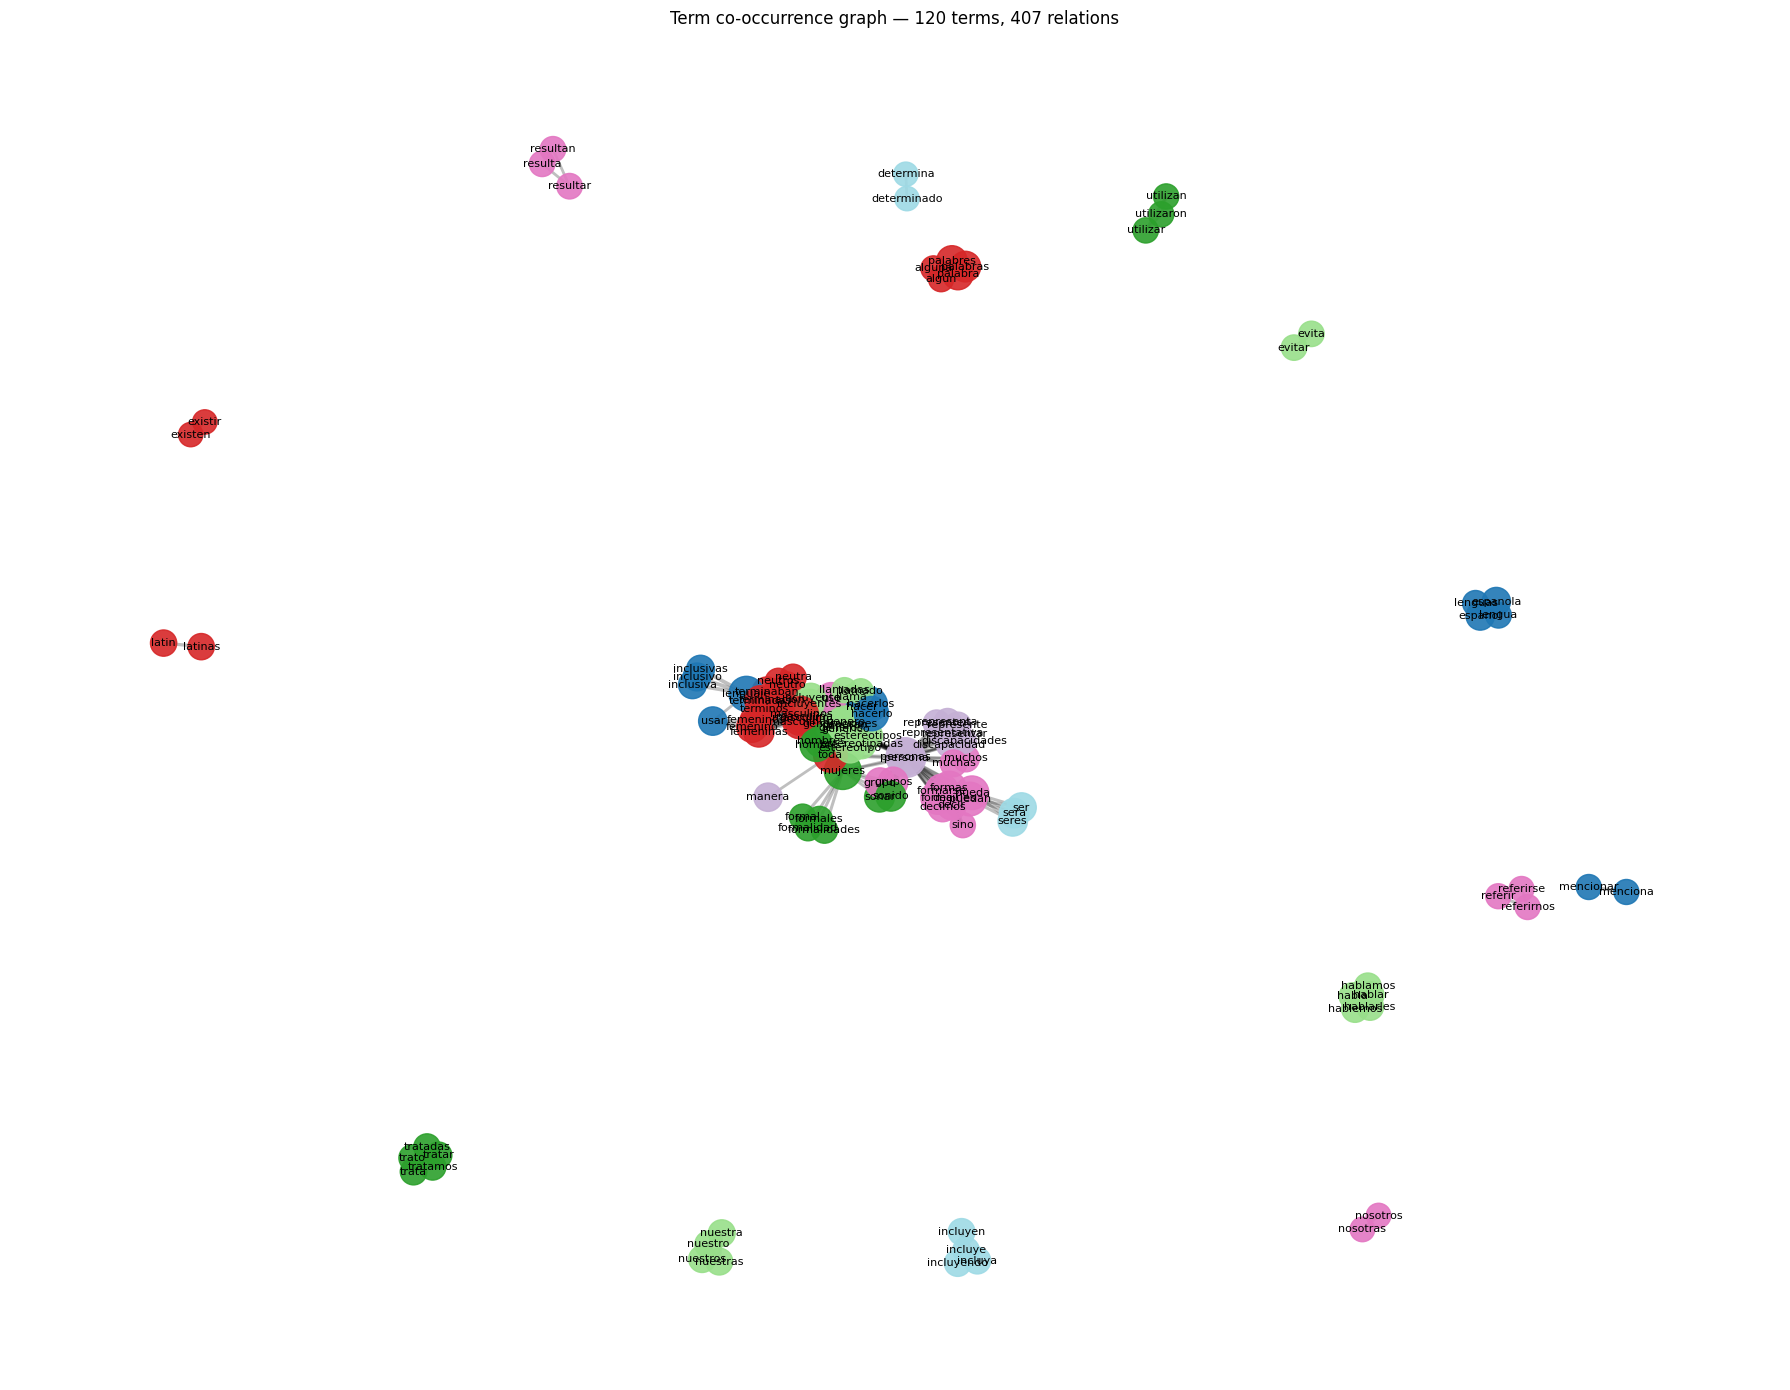

In [108]:
import matplotlib.pyplot as plt


def graph_for_visualization(
    graph: nx.Graph,
    max_nodes: int = 120,
    max_edges: int = 500,
    min_weight: int = 2,
) -> nx.Graph:
    eligible_edges = [
        (source, target, data)
        for source, target, data in graph.edges(data=True)
        if data.get("weight", 1) >= min_weight
    ]
    eligible_edges.sort(
        key=lambda edge: edge[2].get("weight", 1),
        reverse=True,
    )
    eligible_edges = eligible_edges[:max_edges]

    nodes_in_edges = {
        node
        for source, target, _ in eligible_edges
        for node in (source, target)
    }

    ranked_nodes = sorted(
        nodes_in_edges,
        key=lambda node: graph.nodes[node].get("weighted_degree", 0),
        reverse=True,
    )[:max_nodes]

    selected_nodes = set(ranked_nodes)
    selected_edges = [
        (source, target)
        for source, target, _ in eligible_edges
        if source in selected_nodes and target in selected_nodes
    ]

    return graph.edge_subgraph(selected_edges).copy()


visual_graph = graph_for_visualization(
    term_graph,
    max_nodes=VISUALIZATION_MAX_NODES,
    max_edges=VISUALIZATION_MAX_EDGES,
    min_weight=VISUALIZATION_MIN_WEIGHT,
)

plt.figure(figsize=(18, 14))
positions = nx.spring_layout(
    visual_graph,
    weight="weight",
    seed=42,
    k=max(0.15, 1 / np.sqrt(max(visual_graph.number_of_nodes(), 1))),
)

node_sizes = [
    100 + 35 * np.sqrt(visual_graph.nodes[node].get("weighted_degree", 1))
    for node in visual_graph.nodes
]
node_colors = [
    visual_graph.nodes[node].get("community", 0)
    for node in visual_graph.nodes
]
edge_widths = [
    0.4 + np.log1p(data.get("weight", 1))
    for _, _, data in visual_graph.edges(data=True)
]

nx.draw_networkx_edges(
    visual_graph,
    positions,
    width=edge_widths,
    alpha=0.25,
)
nx.draw_networkx_nodes(
    visual_graph,
    positions,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    alpha=0.9,
)
nx.draw_networkx_labels(
    visual_graph,
    positions,
    font_size=8,
)

plt.title(
    f"Term co-occurrence graph — "
    f"{visual_graph.number_of_nodes()} terms, "
    f"{visual_graph.number_of_edges()} relations"
)
plt.axis("off")
plt.tight_layout()
plt.show()


## 17. Interactive PyVis visualization

Hover over a node to inspect frequency, degree and community. Hover over an edge to inspect its weight and time windows. The generated HTML file can be opened independently in a browser.

In [109]:
from pyvis.network import Network
from IPython.display import HTML, display


def create_interactive_graph(
    graph: nx.Graph,
    html_path: Path,
    height: str = "800px",
) -> Path:
    network = Network(
        height=height,
        width="100%",
        bgcolor="#ffffff",
        font_color="#222222",
        notebook=True,
        cdn_resources="in_line",
        select_menu=True,
        filter_menu=True,
    )

    for node, attributes in graph.nodes(data=True):
        weighted_degree = float(attributes.get("weighted_degree", 0))
        community = int(attributes.get("community", 0))
        title = (
            f"<b>{node}</b><br>"
            f"Community: {community}<br>"
            f"Frequency: {attributes.get('frequency', 0)}<br>"
            f"Sentence frequency: {attributes.get('sentence_frequency', 0)}<br>"
            f"Degree: {attributes.get('degree', 0)}<br>"
            f"Weighted degree: {weighted_degree:.1f}"
        )

        network.add_node(
            node,
            label=node,
            title=title,
            value=max(1, weighted_degree),
            group=community,
        )

    for source, target, attributes in graph.edges(data=True):
        time_windows = attributes.get("time_windows", [])
        displayed_windows = time_windows[:20]
        remaining = len(time_windows) - len(displayed_windows)

        title = (
            f"<b>{source} ↔ {target}</b><br>"
            f"Shared contexts: {attributes.get('weight', 1)}<br>"
            + "<br>".join(displayed_windows)
        )
        if remaining > 0:
            title += f"<br>… and {remaining} more time windows"

        network.add_edge(
            source,
            target,
            value=float(attributes.get("weight", 1)),
            title=title,
        )

    network.set_options(
        """
        {
          "interaction": {
            "hover": true,
            "navigationButtons": true,
            "keyboard": true
          },
          "physics": {
            "solver": "forceAtlas2Based",
            "forceAtlas2Based": {
              "gravitationalConstant": -55,
              "centralGravity": 0.01,
              "springLength": 120,
              "springConstant": 0.08,
              "damping": 0.5
            },
            "stabilization": {
              "enabled": true,
              "iterations": 600
            }
          },
          "edges": {
            "smooth": false,
            "scaling": {
              "min": 1,
              "max": 10
            }
          },
          "nodes": {
            "shape": "dot",
            "scaling": {
              "min": 8,
              "max": 35
            }
          }
        }
        """
    )

    network.write_html(str(html_path), open_browser=False)
    return html_path


interactive_path = create_interactive_graph(
    visual_graph,
    GRAPH_HTML,
)

display(HTML(interactive_path.read_text(encoding="utf-8")))
print(f"Interactive graph saved to: {interactive_path.resolve()}")


Interactive graph saved to: /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/term_relationships_interactive.html


## 18. Export graph and relation data

In [110]:
def serialise_list_columns(dataframe: pd.DataFrame) -> pd.DataFrame:
    result = dataframe.copy()
    list_columns = [
        "time_windows",
        "sentence_ids",
        "supporting_sentences",
        "source_forms",
        "target_forms",
    ]
    for column in list_columns:
        if column in result:
            result[column] = result[column].apply(
                lambda value: json.dumps(value, ensure_ascii=False)
            )
    return result


serialised_relationships = serialise_list_columns(relationship_df)
serialised_relationships.to_csv(
    RELATIONSHIPS_CSV,
    index=False,
    encoding="utf-8-sig",
)
community_df.to_csv(
    COMMUNITIES_CSV,
    index=False,
    encoding="utf-8-sig",
)

# GraphML and GEXF accept scalar attributes. Export a copy with lists encoded as JSON.
export_graph = term_graph.copy()
for _, _, attributes in export_graph.edges(data=True):
    for key in [
        "time_windows",
        "sentence_ids",
        "supporting_sentences",
        "source_forms",
        "target_forms",
    ]:
        if key in attributes:
            attributes[key] = json.dumps(
                attributes[key],
                ensure_ascii=False,
            )

nx.write_graphml(export_graph, GRAPH_GRAPHML)
nx.write_gexf(export_graph, GRAPH_GEXF)

print(f"Relationships CSV: {RELATIONSHIPS_CSV.resolve()}")
print(f"Communities CSV:   {COMMUNITIES_CSV.resolve()}")
print(f"GraphML:           {GRAPH_GRAPHML.resolve()}")
print(f"GEXF:              {GRAPH_GEXF.resolve()}")
print(f"Interactive HTML:  {GRAPH_HTML.resolve()}")


Relationships CSV: /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/term_relationships.csv
Communities CSV:   /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/term_communities.csv
GraphML:           /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/term_relationships.graphml
GEXF:              /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/term_relationships.gexf
Interactive HTML:  /content/drive/MyDrive/1-ACADEMIKA/PHD-INTERNS/UJAEN/podcasts/youtube_transcriptions/wtpDYqlcMUg/srt_analysis_output/term_relationships_interactive.html


# Optional Neo4j storage and navigation

The next cells are optional. They require a running Neo4j database.

For community detection inside Neo4j, install the Graph Data Science plugin or use a Neo4j deployment that includes GDS. The notebook first imports the graph through the official Python driver and then supplies Cypher/GDS queries.


## 19. Neo4j connection configuration

In [ ]:
import os
from getpass import getpass

# Examples:
# NEO4J_URI = "neo4j://localhost:7687"
# NEO4J_URI = "neo4j+s://<database-id>.databases.neo4j.io"
NEO4J_URI = os.getenv("NEO4J_URI", "neo4j://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_DATABASE = os.getenv("NEO4J_DATABASE", "neo4j")

# Do not store a password directly in a shared notebook.
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD") or getpass("Neo4j password: ")


## 20. Connect and verify the database

In [ ]:
from neo4j import GraphDatabase

driver = GraphDatabase.driver(
    NEO4J_URI,
    auth=(NEO4J_USER, NEO4J_PASSWORD),
)
driver.verify_connectivity()

records, summary, keys = driver.execute_query(
    "RETURN 'Connected to Neo4j' AS message, "
    "       elementId(db) AS databaseElementId",
    database_=NEO4J_DATABASE,
)

print(records[0]["message"])


## 21. Prepare Neo4j node and relationship records

Supporting sentences can make individual relationships large. The import below stores sentence IDs and time windows on each relationship, while keeping full supporting sentences in the CSV export.

In [ ]:
node_records = []
for node, attributes in term_graph.nodes(data=True):
    node_records.append({
        "term": node,
        "frequency": int(attributes.get("frequency", 0)),
        "sentenceFrequency": int(attributes.get("sentence_frequency", 0)),
        "relativeFrequency": float(attributes.get("relative_frequency", 0.0)),
        "degree": int(attributes.get("degree", 0)),
        "weightedDegree": float(attributes.get("weighted_degree", 0.0)),
        "localCommunity": int(attributes.get("community", -1)),
        "videoId": metadata["video_id"],
    })

relationship_records = []
for source, target, attributes in term_graph.edges(data=True):
    relationship_records.append({
        "source": source,
        "target": target,
        "weight": int(attributes.get("weight", 1)),
        "distinctTimeWindows": int(attributes.get("distinct_time_windows", 0)),
        "timeWindows": [str(x) for x in attributes.get("time_windows", [])],
        "sentenceIds": [int(x) for x in attributes.get("sentence_ids", [])],
        "videoId": metadata["video_id"],
    })

print(f"Node records: {len(node_records):,}")
print(f"Relationship records: {len(relationship_records):,}")


## 22. Create constraints and import the graph

In [ ]:
# Term IDs are scoped to the video so that several videos can coexist.
driver.execute_query(
    """
    CREATE CONSTRAINT term_video_unique IF NOT EXISTS
    FOR (t:Term)
    REQUIRE (t.term, t.videoId) IS UNIQUE
    """,
    database_=NEO4J_DATABASE,
)

driver.execute_query(
    """
    UNWIND $rows AS row
    MERGE (t:Term {term: row.term, videoId: row.videoId})
    SET t.frequency = row.frequency,
        t.sentenceFrequency = row.sentenceFrequency,
        t.relativeFrequency = row.relativeFrequency,
        t.degree = row.degree,
        t.weightedDegree = row.weightedDegree,
        t.localCommunity = row.localCommunity
    """,
    rows=node_records,
    database_=NEO4J_DATABASE,
)

driver.execute_query(
    """
    UNWIND $rows AS row
    MATCH (source:Term {term: row.source, videoId: row.videoId})
    MATCH (target:Term {term: row.target, videoId: row.videoId})
    MERGE (source)-[relation:RELATED_TO {
        videoId: row.videoId,
        pairKey: CASE
            WHEN row.source < row.target
            THEN row.source + '||' + row.target
            ELSE row.target + '||' + row.source
        END
    }]-(target)
    SET relation.weight = row.weight,
        relation.distinctTimeWindows = row.distinctTimeWindows,
        relation.timeWindows = row.timeWindows,
        relation.sentenceIds = row.sentenceIds
    """,
    rows=relationship_records,
    database_=NEO4J_DATABASE,
)

records, _, _ = driver.execute_query(
    """
    MATCH (t:Term {videoId: $video_id})
    OPTIONAL MATCH (t)-[r:RELATED_TO {videoId: $video_id}]-()
    RETURN count(DISTINCT t) AS terms,
           count(DISTINCT r) AS relations
    """,
    video_id=metadata["video_id"],
    database_=NEO4J_DATABASE,
)

print(dict(records[0]))


## 23. Cypher navigation queries

Each cell below can be edited independently. The first examples work in standard Neo4j without GDS.


In [ ]:
# A. Most strongly connected terms by weighted degree
records, _, _ = driver.execute_query(
    '''
    MATCH (term:Term {videoId: $video_id})-[relation:RELATED_TO]-()
    RETURN term.term AS term,
           count(relation) AS degree,
           sum(relation.weight) AS weightedDegree
    ORDER BY weightedDegree DESC, degree DESC
    LIMIT 30
    ''',
    video_id=metadata["video_id"],
    database_=NEO4J_DATABASE,
)

display(pd.DataFrame([dict(record) for record in records]))


In [ ]:
# B. Direct neighbours of a chosen term, including relation time windows
NEO4J_TERM = "deporte"

records, _, _ = driver.execute_query(
    '''
    MATCH (term:Term {term: $term, videoId: $video_id})
          -[relation:RELATED_TO]-
          (neighbour:Term {videoId: $video_id})
    RETURN neighbour.term AS relatedTerm,
           relation.weight AS sharedContexts,
           relation.timeWindows AS timeWindows
    ORDER BY sharedContexts DESC, relatedTerm
    ''',
    term=normalise_text(NEO4J_TERM),
    video_id=metadata["video_id"],
    database_=NEO4J_DATABASE,
)

display(pd.DataFrame([dict(record) for record in records]))


In [ ]:
# C. Relations active during a time-window prefix, for example the first minute '00:00'
TIME_PREFIX = "00:00"

records, _, _ = driver.execute_query(
    '''
    MATCH (source:Term {videoId: $video_id})
          -[relation:RELATED_TO {videoId: $video_id}]-
          (target:Term {videoId: $video_id})
    WHERE any(window IN relation.timeWindows
              WHERE window STARTS WITH $time_prefix)
      AND source.term < target.term
    RETURN source.term AS source,
           target.term AS target,
           relation.weight AS weight,
           [window IN relation.timeWindows
            WHERE window STARTS WITH $time_prefix] AS matchingWindows
    ORDER BY weight DESC
    LIMIT 100
    ''',
    video_id=metadata["video_id"],
    time_prefix=TIME_PREFIX,
    database_=NEO4J_DATABASE,
)

display(pd.DataFrame([dict(record) for record in records]))


In [ ]:
# D. Shortest semantic/co-occurrence path between two terms
SOURCE_TERM = "deporte"
TARGET_TERM = "discriminacion"

records, _, _ = driver.execute_query(
    '''
    MATCH (source:Term {term: $source, videoId: $video_id}),
          (target:Term {term: $target, videoId: $video_id})
    MATCH path = shortestPath(
        (source)-[:RELATED_TO*..8]-(target)
    )
    RETURN [node IN nodes(path) | node.term] AS terms,
           [relation IN relationships(path) | relation.weight] AS weights,
           length(path) AS pathLength
    ''',
    source=normalise_text(SOURCE_TERM),
    target=normalise_text(TARGET_TERM),
    video_id=metadata["video_id"],
    database_=NEO4J_DATABASE,
)

display(pd.DataFrame([dict(record) for record in records]))


In [ ]:
# E. Terms that link otherwise different local communities
records, _, _ = driver.execute_query(
    '''
    MATCH (term:Term {videoId: $video_id})-[relation:RELATED_TO]-
          (neighbour:Term {videoId: $video_id})
    WITH term,
         collect(DISTINCT neighbour.localCommunity) AS neighbourCommunities,
         sum(relation.weight) AS totalWeight
    WHERE size(neighbourCommunities) >= 2
    RETURN term.term AS bridgeTerm,
           term.localCommunity AS ownCommunity,
           neighbourCommunities,
           size(neighbourCommunities) AS communitiesReached,
           totalWeight
    ORDER BY communitiesReached DESC, totalWeight DESC
    LIMIT 50
    ''',
    video_id=metadata["video_id"],
    database_=NEO4J_DATABASE,
)

display(pd.DataFrame([dict(record) for record in records]))


## 24. Neo4j Graph Data Science: project the graph

This section requires the GDS plugin. It projects only the current video's terms and relations as an undirected weighted graph. The Cypher projection keeps several videos isolated from one another.


In [ ]:
GDS_GRAPH_NAME = f"termGraph_{metadata['video_id'].replace('-', '_')}"

# Remove an earlier in-memory projection with the same name.
driver.execute_query(
    '''
    CALL gds.graph.exists($graph_name)
    YIELD exists
    WITH exists
    WHERE exists
    CALL gds.graph.drop($graph_name, false)
    YIELD graphName
    RETURN graphName
    ''',
    graph_name=GDS_GRAPH_NAME,
    database_=NEO4J_DATABASE,
)

records, _, _ = driver.execute_query(
    '''
    MATCH (source:Term {videoId: $video_id})
    OPTIONAL MATCH (source)-[relation:RELATED_TO {videoId: $video_id}]-
                   (target:Term {videoId: $video_id})
    WITH gds.graph.project(
        $graph_name,
        source,
        target,
        {
          relationshipProperties:
            CASE
              WHEN relation IS NULL
              THEN {}
              ELSE {weight: relation.weight}
            END,
          undirectedRelationshipTypes:
            CASE
              WHEN relation IS NULL
              THEN []
              ELSE ['RELATED_TO']
            END
        }
    ) AS graph
    RETURN graph.graphName AS graphName,
           graph.nodeCount AS nodeCount,
           graph.relationshipCount AS relationshipCount
    ''',
    graph_name=GDS_GRAPH_NAME,
    video_id=metadata["video_id"],
    database_=NEO4J_DATABASE,
)

display(pd.DataFrame([dict(record) for record in records]))


## 25. Find and store communities with Leiden

Leiden partitions terms into densely connected groups. `write` mode stores the resulting identifier in each `Term.gdsCommunity` property.


In [ ]:
records, _, _ = driver.execute_query(
    '''
    CALL gds.leiden.write(
        $graph_name,
        {
          relationshipWeightProperty: 'weight',
          writeProperty: 'gdsCommunity',
          randomSeed: 42
        }
    )
    YIELD communityCount,
          modularity,
          nodePropertiesWritten,
          ranLevels
    RETURN communityCount,
           modularity,
           nodePropertiesWritten,
           ranLevels
    ''',
    graph_name=GDS_GRAPH_NAME,
    database_=NEO4J_DATABASE,
)

display(pd.DataFrame([dict(record) for record in records]))


In [ ]:
# F. Community summaries and representative terms
records, _, _ = driver.execute_query(
    '''
    MATCH (term:Term {videoId: $video_id})
    WHERE term.gdsCommunity IS NOT NULL
    WITH term.gdsCommunity AS community,
         term
    ORDER BY community, term.weightedDegree DESC
    WITH community,
         collect({
             term: term.term,
             weightedDegree: term.weightedDegree,
             frequency: term.frequency
         }) AS rankedTerms
    RETURN community,
           size(rankedTerms) AS communitySize,
           rankedTerms[..15] AS representativeTerms
    ORDER BY communitySize DESC
    ''',
    video_id=metadata["video_id"],
    database_=NEO4J_DATABASE,
)

display(pd.DataFrame([dict(record) for record in records]))


In [ ]:
# G. Internal and external links for one community
COMMUNITY_ID = 0

records, _, _ = driver.execute_query(
    '''
    MATCH (term:Term {
        videoId: $video_id,
        gdsCommunity: $community_id
    })-[relation:RELATED_TO]-
    (neighbour:Term {videoId: $video_id})
    RETURN term.term AS term,
           neighbour.term AS neighbour,
           neighbour.gdsCommunity AS neighbourCommunity,
           relation.weight AS weight,
           CASE
             WHEN neighbour.gdsCommunity = $community_id
             THEN 'internal'
             ELSE 'external'
           END AS linkType,
           relation.timeWindows AS timeWindows
    ORDER BY linkType, weight DESC
    LIMIT 200
    ''',
    video_id=metadata["video_id"],
    community_id=COMMUNITY_ID,
    database_=NEO4J_DATABASE,
)

display(pd.DataFrame([dict(record) for record in records]))


## 26. Optional GDS centrality queries

PageRank identifies globally prominent terms. Betweenness centrality identifies terms that bridge different parts of the discourse graph.


In [ ]:
# H. Weighted PageRank
records, _, _ = driver.execute_query(
    '''
    CALL gds.pageRank.stream(
        $graph_name,
        {relationshipWeightProperty: 'weight'}
    )
    YIELD nodeId, score
    RETURN gds.util.asNode(nodeId).term AS term,
           score
    ORDER BY score DESC
    LIMIT 30
    ''',
    graph_name=GDS_GRAPH_NAME,
    database_=NEO4J_DATABASE,
)

display(pd.DataFrame([dict(record) for record in records]))


In [ ]:
# I. Betweenness centrality: terms that act as bridges
records, _, _ = driver.execute_query(
    '''
    CALL gds.betweenness.stream($graph_name)
    YIELD nodeId, score
    RETURN gds.util.asNode(nodeId).term AS term,
           score
    ORDER BY score DESC
    LIMIT 30
    ''',
    graph_name=GDS_GRAPH_NAME,
    database_=NEO4J_DATABASE,
)

display(pd.DataFrame([dict(record) for record in records]))


## 27. Close the Neo4j connection

Run this after finishing the database operations.

In [ ]:
driver.close()
print("Neo4j connection closed.")


## Interpretation cautions

- Co-occurrence is a **contextual association**, not necessarily causation, agreement or semantic equivalence.
- Stemming may merge related grammatical forms but can also create false matches. Use strict matching for sensitive interpretation.
- Very frequent generic terms can dominate weighted graphs. Stop-word removal and a higher `MIN_SHARED_CONTEXTS` threshold can improve interpretability.
- Community identifiers are arbitrary labels. Interpret a community through its representative terms, supporting sentences and time windows.
- A community algorithm may produce somewhat different partitions when thresholds, weights or random seeds change.
- For larger corpora, consider adding `Video`, `Sentence`, `Speaker` and `TimeWindow` nodes rather than storing all evidence only as relationship properties.
